# Load Data

choice_numeric_last
0.0    11221
1.0     3359
Name: count, dtype: int64
81


0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
14575    1.0
14576    NaN
14577    1.0
14578    1.0
14579    1.0
Name: correct_control_action, Length: 14580, dtype: float64
correct_control_action
1.000000    12021
0.000000     1299
0.500000       96
0.333333       72
0.666667       33
Name: count, dtype: int64


81


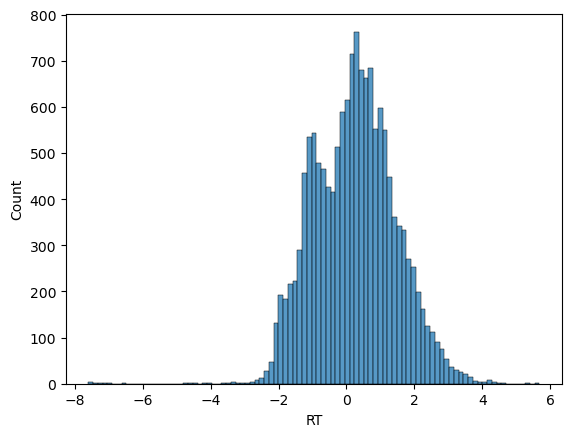

Index(['Unnamed: 0', 'sub', 'trial_num', 'trial_num_within_goal',
       'current_state', 'decision', 'got_to_goal', 'got_to_goal_last',
       'goal_switch', 'control_regressor', 'RT', 'eligible_decisions_accuracy',
       'retrieved_cached', 'planning_depth', 'delayed_planning', 'choices',
       'worry', 'optimally_delayed', 'optimally_control_choice',
       'optimally_delayed_last', 'choice_numeric', 'choices_numeric',
       'choice_numeric_last', 'interaction_won_and_metachoice',
       'got_to_goal_retrieved_cached', 'MB_decision',
       'optimal_metacontrol_choice', 'over_planning', 'over_control',
       'optimal_metacontrol_choice_last', 'points_from_choice',
       'points_from_goal', 'trial_points', 'total_points',
       'correct_control_action', 'space_hit_points', 'goal_points',
       'space_hit_points_total', 'total_score', 'metacontrol_accuracy',
       'percent_correct', 'bad_planning', 'rawRT'],
      dtype='object')


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr as corrp
import csv
import matplotlib.pyplot as plt
import arviz as az
import seaborn as sns

df=pd.read_csv('preprocessed_data.csv')
df['choice_numeric'] = [1 if choice == 'space' else 0 for choice in df['choices']]
df['choices_numeric'] = [0 if choice == 'left' else 1 if choice=='right' else 2 for choice in df['choices']]

# Step 1: Filter df where planning_depth == 3 and decision == 1
filtered_df = df[(df['planning_depth'] == 3)]
# Step 2: Group by 'sub' and count the number of 1s in 'choice_numeric'
counts = filtered_df.groupby('sub')['choice_numeric'].apply(lambda x: (x == 1).sum())

# Step 3: Identify subjects with more than 15 1s
subjects_to_exclude = counts[counts > 60].index

# Step 4: Exclude these subjects from df
df = df[~df['sub'].isin(subjects_to_exclude)]


# Initially, create the 'choice_numeric_last' column by shifting 'choice_numeric'
# Sort the DataFrame by subject_id, planning_depth, trial_id, and decision
df_sorted = df.sort_values(by=['sub', 'planning_depth','trial_num_within_goal', 'decision'])

# Group by subject_id, planning_depth, and decision, then shift the choice_numeric column to get the previous trial's choice
df['choice_numeric_last'] = df_sorted.groupby(['sub', 'planning_depth', 'decision'])['choice_numeric'].shift(1)

# Now, identify the first trial within each planning depth for each subject
# To do this, we can use a combination of groupby and transform to mark the first trial's rows
df['is_first_trial'] = df.groupby(['sub', 'planning_depth'])['trial_num'].transform(lambda x: x == x.min())

# Set 'choice_numeric_last' to 0 for all decisions within the first trial of each planning depth
df.loc[df['is_first_trial'] == True, 'choice_numeric_last'] = 0

# Drop the helper column 'is_first_trial' if it's no longer needed
df.drop(columns=['is_first_trial'], inplace=True)

# Ensure there are no NaN values in 'choice_numeric_last'; fill with 0 if any (should be redundant by now)
# Fill NaN values with 0, as these represent the first trial of each goal within each subject
print(df['choice_numeric_last'].value_counts())

df['choice_numeric_last'] = df['choice_numeric_last'].fillna(0)

df['interaction_won_and_metachoice'] = [
    1 if got_to_goal_last == 1 and choice_numeric_last == 1 
    else -1 if got_to_goal_last == 0 and choice_numeric_last == 1 
    else 0 if got_to_goal_last == 0 and choice_numeric_last == 0 
    else 0 if got_to_goal_last == 1 and choice_numeric_last == 0 
    else 0
    for got_to_goal_last, choice_numeric_last in zip(df['got_to_goal_last'], df['choice_numeric_last'])
]

df['got_to_goal_retrieved_cached'] = [
    'Won_Cached' if got_to_goal == 1 and retrieved_cached == 1 
    else 'Lost_Cached' if got_to_goal == 0 and retrieved_cached == 1 
    else 'Won_Novel' if got_to_goal == 0 and retrieved_cached == 0 
    else 'Lost_Novel' if got_to_goal == 1 and retrieved_cached == 0 
    else 0
    for got_to_goal, retrieved_cached in zip(df['got_to_goal'], df['retrieved_cached'])
]

# This solution takes into account the structure of your data, where each subject can have multiple goals
# defined by 'planning_depth', and each goal consists of 20 trials defined by 'trial_num_within_goal'.
# By grouping by both 'subject' and 'planning_depth', the 'choice_numeric_last' column is correctly calculated
# within the context of each goal, ensuring the integrity of the sequence for each goal within each subject.

# Fill NaN values (which will be present for the first trial of each subject) with 0

# This approach 
df=df.reset_index(drop=True)
print(len(df['sub'].unique()))




def calculate_optimal_metacontrol_choice(row):
    if row['planning_depth'] == 3:
        return 1 if row['choice_numeric'] == 0 else 0
    elif row['planning_depth'] == 2:
        if row['decision'] == 1:
            return 1 if row['choice_numeric'] == 1 else 0
        elif row['decision'] in [2, 3]:
            return 1 if row['choice_numeric'] == 0 else 0
        else:
            return 0
    elif row['planning_depth'] == 1:
        if row['decision'] in [1, 2]:
            return 1 if row['choice_numeric'] == 1 else 0
        elif row['decision'] == 3:
            return 1 if row['choice_numeric'] == 0 else 0
        else:
            return 0
    else:
        return 0


def create_optimal_mc(row): #points at which you should relinquish control
    if row['planning_depth'] == 3:
        return 0
    elif row['planning_depth'] == 2:
        if row['decision'] == 1:
            return 1
        elif row['decision'] in [2, 3]:
            return 1 if row['choice_numeric'] == 0 else 0
        else:
            return 0
    elif row['planning_depth'] == 1:
        if row['decision'] in [1, 2]:
            return 1 if row['choice_numeric'] == 1 else 0
        elif row['decision'] == 3:
            return 1 if row['choice_numeric'] == 0 else 0
        else:
            return 0
    else:
        return 0

def create_overcontrol(row): #points at which you should relinquish control
    if row['planning_depth'] == 3:
        if row['optimal_metacontrol_choice']==0:
            return 0
        else:
            return 0
    elif row['planning_depth'] == 2:
        if row['decision'] == 1:
            if row['optimal_metacontrol_choice']==0:
                return 1
            else:
                return -1
        elif row['decision'] in [2, 3]:
            if row['optimal_metacontrol_choice']==0:
                return 0
            else:
                return 0
        
    elif row['planning_depth'] == 1:
        if row['decision'] in [1, 2]:
            if row['optimal_metacontrol_choice']==0:
                return 1
            else:
                return -1
        elif row['decision'] == 3:
            if row['optimal_metacontrol_choice']==0:
                return 0
            else:
                return 0

# Initialize the dictionary
correct_MB_choices = {}

# Assuming df['current_state'] exists and represents the state at the time of making the decision
# Filter the DataFrame for rows where got_to_goal == 1
got_to_goal_df = df[df['got_to_goal'] == 1]

# Populate the dictionary with (planning_depth, decision, current_state) as keys
for _, row in got_to_goal_df.iterrows():
    key = (row['planning_depth'], row['decision'], row['current_state'])
    value = row['choices_numeric']
    # Ensure each key is unique to maintain consistency
    if key not in correct_MB_choices:
        correct_MB_choices[key] = value

def create_MB_decision(row):
    """
    Assigns a value to MB_decision based on the specified logic and the correct_MB_choices dictionary,
    now considering the triplet combination of planning_depth, decision, and current_state.
    
    Parameters:
    - row: a row from the DataFrame.
    
    Returns:
    - The value for MB_decision for the row.
    """
    # Direct conditions
    if row['planning_depth'] == 2 and row['decision'] == 1:
        return 2
    elif row['planning_depth'] == 1 and row['decision'] in [1, 2]:
        return 2
    else:
        # Reference the dictionary with the triplet key
        key = (row['planning_depth'], row['decision'], row['current_state'])
        return correct_MB_choices.get(key, -10)

# Apply the function to each row of the DataFrame
df['MB_decision'] = df.apply(create_MB_decision, axis=1)

    

def create_overplanning(row): #points at which you should relinquish control
    if row['planning_depth'] == 3:
        if row['decision']>1:
            return 1
        else:
            return 0
    elif row['planning_depth'] == 2:
        if row['decision'] == 3:
            return 1
        else:
            return 0
    elif row['planning_depth'] == 1:
        return 0
    else:
        return 0
sd_RT=df['RT'].std()
mean_RT=df['RT'].mean()





# Apply the function to each row
df['optimal_metacontrol_choice'] = df.apply(calculate_optimal_metacontrol_choice, axis=1)
# df['optimal_metacontrol_choice_accurate'] = df.apply(calculate_optimal_metacontrol_choice_accounting_for_accuracy, axis=1)

df['over_planning'] = df.apply(create_overplanning, axis=1)
df['over_control'] = df.apply(create_overcontrol, axis=1)

df['optimal_metacontrol_choice_last'] = df.groupby(['sub', 'planning_depth'])['optimal_metacontrol_choice'].shift()

# Now, identify the first trial within each planning depth for each subject
# To do this, we can use a combination of groupby and transform to mark the first trial's rows
df['is_first_trial'] = df.groupby(['sub', 'planning_depth'])['trial_num'].transform(lambda x: x == x.min())

# Set 'choice_numeric_last' to 0 for all decisions within the first trial of each planning depth
df.loc[df['is_first_trial'] == True, 'optimal_metacontrol_choice_last'] = 0

# Drop the helper column 'is_first_trial' if it's no longer needed
df.drop(columns=['is_first_trial'], inplace=True)
# df.drop(columns=['choices'], inplace=True)

# Ensure there are no NaN values in 'choice_numeric_last'; fill with 0 if any (should be redundant by now)
# Fill NaN values with 0, as these represent the first trial of each goal within each subject
df['optimal_metacontrol_choice_last'] = df['optimal_metacontrol_choice_last'].fillna(0)

# Adjusted Step 1: Calculate points from numeric_choice directly, with modification for non-goal-achieving actions
df['points_from_choice'] = df.apply(lambda row: -100 if row['choice_numeric'] == 1 and not row['got_to_goal'] else row['choice_numeric'] * 100, axis=1)

# Step 2: For each trial, determine if got_to_goal was achieved at least once
# This remains unchanged as it correctly calculates points from achieving goals
got_to_goal_per_trial = df.groupby(['sub', 'trial_num'])['got_to_goal'].max().reset_index()
got_to_goal_per_trial['points_from_goal'] = got_to_goal_per_trial['got_to_goal'] * 400
# Merge this back with the original df to associate points_from_goal with each decision
df = df.merge(got_to_goal_per_trial[['sub', 'trial_num', 'points_from_goal']], on=['sub', 'trial_num'], how='left')

# Now, calculate trial_points by summing points_from_choice and points_from_goal for each trial
# This step remains unchanged as it depends on the updated calculation from Step 1
df['trial_points'] = df.groupby(['sub', 'trial_num'])['points_from_choice'].transform('sum') + df['points_from_goal']

# Step 3: Calculate total_points for each subject by summing trial_points
# This step remains unchanged as it correctly sums up the trial points to calculate total points per subject
total_points_per_subject = df.groupby(['sub'])['trial_points'].sum().reset_index(name='total_points')

# If needed, merge total_points back to the original df
# This step ensures each participant's total points are reflected in the original dataframe
df = df.merge(total_points_per_subject[['sub', 'total_points']], on='sub', how='left')

#correct control actions

#transition structure deterministic where red is right, and blue is left



# Deterministic transition structure
deterministic_transitions = {
    ('start', 'red'): 'toothbrush',
    ('start', 'blue'): 'baby',
    ('baby', 'red'): 'bowtie',
    ('baby', 'blue'): 'backpack',
    ('toothbrush', 'red'): 'backpack',
    ('toothbrush', 'blue'): 'car',
    ('backpack', 'blue'): 'zebra',
    ('backpack', 'red'): 'lamp',
    ('bowtie', 'blue'): 'lamp',
    ('bowtie', 'red'): 'knight',
    ('car', 'blue'): 'cat',
    ('car', 'red'): 'lamp'
}
# Recursive helper function to find future states
def find_future_states(state, transitions, visited=None):
    if visited is None:
        visited = set()
    if state in visited:
        return set()
    visited.add(state)
    next_states = {transitions[s] for s in transitions if s[0] == state}
    all_future_states = set(next_states)
    for ns in next_states:
        all_future_states.update(find_future_states(ns, transitions, visited))
    return all_future_states



# To respect the original order of the DataFrame (grouped by decision across all trials),
# we need to build the results array in the same row order as the original DataFrame.

# First, save the original order using an index column
df['original_index'] = df.index

# Recompute correct_control_action values based on trial groupings
correct_action_values = []

# Create a temporary column for correct values, to merge back in order later
temp_df = pd.DataFrame(columns=['original_index', 'correct_control_action'])

for (sub, trial_num), group in df.groupby(['sub', 'trial_num']):
    goal = group['planning_depth'].iloc[0]
    gtg = group['got_to_goal'].iloc[0]
    goal_map = {3: 'cat', 2: 'zebra', 1: 'lamp'}
    critical_decisions_map = {3: 0, 2: 1, 1: 2}
    target_goal = goal_map[goal]
    critical_decision_threshold=critical_decisions_map[goal]
    state = 'start'

    correct_choices = 0
    control_choices = 0

    for _, row in group.sort_values('decision').iterrows():
        
        state = row['current_state']
        if state != 'start':
            state = state[7:-4]
        decision=row['decision']
        # print(decision)

        choice = row['choices']
        if decision>critical_decision_threshold:
            if choice != 'space':
                control_choices += 1
                choice_direction = 'red' if choice == 'right' else 'blue'
                correct_state = deterministic_transitions.get((state, choice_direction))
                if decision==3:
                    if gtg:
                        correct_choices+=1
                else:
                    
                    if target_goal in find_future_states(correct_state, deterministic_transitions):
                        correct_choices+=1
    percent_correct = np.nan if control_choices == 0 else correct_choices/control_choices
   

    for idx in group.index:
        temp_df.loc[len(temp_df)] = [idx, percent_correct]

# Sort the result to match the original order
temp_df = temp_df.sort_values('original_index')
df = df.sort_values('original_index').drop(columns=['original_index'])

# Merge correct values into main df
df['correct_control_action'] = temp_df['correct_control_action'].values
print(df['correct_control_action'])


# Add space_hit_points: 1 point for each space hit (choice_numeric == 1)
df['space_hit_points'] = df['choice_numeric']

# Add goal_points: 4 points if the goal was reached in that trial
goal_points_df = df.groupby(['sub', 'trial_num'])['got_to_goal'].max().reset_index()
goal_points_df['goal_points'] = goal_points_df['got_to_goal'] * 4
df = df.merge(goal_points_df[['sub', 'trial_num', 'goal_points']], on=['sub', 'trial_num'], how='left')

# Sum points per trial
trial_score_df = df.groupby(['sub', 'trial_num'])[['space_hit_points']].sum().reset_index()
df = df.merge(trial_score_df, on=['sub', 'trial_num'], suffixes=('', '_total'))

# Calculate total_score per trial
df['total_score'] = df['goal_points'] + df['space_hit_points_total']

# Final function: compares actual choice (choice_numeric) to optimal meta-control policy
def evaluate_metacontrol_accuracy(row):
    goal_map = {3: 'cat', 2: 'zebra', 1: 'lamp'}
    goal = goal_map.get(row['planning_depth'], None)

    if goal is None:
        return 0

    decision = row['decision']
    depth = row['planning_depth']
    actual_choice = row['choice_numeric']  # 0 = take control, 1 = give up

    # Rule-based optimal meta-control
    if (depth == 2 and decision == 1) or (depth == 1 and decision in [1, 2]):
        optimal_choice = 1
    else:
        state = row['current_state']
        if state != 'start':
            state = state[7:-4]  # Strip 'images/' and '.png'

        reachable_states = find_future_states(state, deterministic_transitions)

        if goal not in reachable_states and goal != state:
            optimal_choice = 1  # Give up control
        else:
            optimal_choice = 0  # Take control

    return 1 if actual_choice == optimal_choice else 0

# Apply to DataFrame
df['metacontrol_accuracy'] = df.apply(evaluate_metacontrol_accuracy, axis=1)

# Apply correctness calculation to df
print(df.correct_control_action.value_counts())


# df['correct_control_action']= [
#     1 if got_to_goal_last == 1 and choice_numeric_last == 0 
#     else 0 if got_to_goal_last == 0 and choice_numeric_last == 0 
#     else 0
#     for got_to_goal_last, choice_numeric_last in zip(df['got_to_goal'], df['choice_numeric'])
# ]

# #save df
df=pd.read_csv('lmm_fixed.csv')

# # df=df[df['RT']<4]


df_memory=pd.read_csv('memory_accuracies_subjects_orig_fulltrajectories.csv')

df = df.merge(df_memory[['sub','percent_correct']], on='sub', how='left')
df=df.reset_index(drop=True)


# Iterate through each subject
for subject_id, subject_data in df.groupby('sub'):
    # Iterate through each trial for the subject
    for trial_id, trial_data in subject_data.groupby('trial_num'):
        # Check if decision 1 is 0 and decision 2 or 3 is 1
        if ((trial_data['decision'] == 1) & (trial_data['choice_numeric'] == 0)).any() and \
           (((trial_data['decision'] == 2) | (trial_data['decision'] == 3)) & (trial_data['choice_numeric'] == 1)).any():
                # Set 'bad_planning' to 1 for this trial
                df.loc[(df['sub'] == subject_id) & (df['trial_num'] == trial_id), 'bad_planning'] = 1
        # Check if decision 1 is 1 and decision 2 or 3 is 0
        elif ((trial_data['decision'] == 2) & (trial_data['choice_numeric'] == 0)).any() and \
             (((trial_data['trial_num'] == 3)) & (trial_data['choice_numeric'] == 1)).any():
                # Set 'bad_planning' to 1 for this trial
                df.loc[(df['sub'] == subject_id) & (df['trial_num'] == trial_id), 'bad_planning'] = 1
            
df['bad_planning'] = df['bad_planning'].replace([np.nan, np.inf], 0)

# df = df[~df['sub'].isin(bad_planning_subs)]
print(len(df['sub'].unique()))
df['rawRT']=np.exp(df['RT'])

sns.histplot(x='RT',data=df) 
plt.show()
# Print the updated DataFrame
print(df.columns)
df_results2=df
df_results2['control taking'] = [0 if choice == 'space' else 1 for choice in df['choices']]


df=df.drop(['current_state','choices',
'got_to_goal_retrieved_cached'],axis=1)

# Overall performance and its relation to memory

In [2]:
# ---------------------------------------------------------------------
# ANALYSIS: first 5 trials
# Goal:
#   • Identify participants who delayed optimally (==1) on **any** depth-3
#     trial within trials 1-5.
#   • For those participants, compute:
#       (a) count of participants,
#       (b) overall mean optimally_delayed for depths 1 & 2
#           pooled across the same 5 trials,
#       (c) (optional) separate means for depth 1 vs 2.
# ---------------------------------------------------------------------

# 0) Subset to trials 1-5
df5 = df[df['trial_num_within_goal'].between(1, 5)].copy()

# 1) Participants with at least one depth-3 success in those trials
depth3_success_mask = (df5['planning_depth'] == 3) & (df5['optimally_delayed'] == 1)
subs_depth3_success = df5.loc[depth3_success_mask, 'sub'].unique()

n_success = len(subs_depth3_success)
print(f'Participants with ≥1 optimal delay at depth-3 (trials 1-5): {n_success}')

# 2) Mean optimally_delayed for depths 1 & 2, same subjects, same trial window
depth12_mask = df5['planning_depth'].isin([1, 2]) & df5['sub'].isin(subs_depth3_success)
overall_avg_depth12 = df5.loc[depth12_mask, 'optimally_delayed'].mean()

print(f'Overall mean optimally_delayed (depths 1 & 2, trials 1-5, same subs): '
      f'{overall_avg_depth12:.3f}')

# 3) (Optional) Separate means for depth 1 and depth 2
separate_means = (
    df5.loc[depth12_mask, ['planning_depth', 'optimally_delayed']]
       .groupby('planning_depth')['optimally_delayed']
       .mean()
       .rename({1: 'depth_1_mean', 2: 'depth_2_mean'})
)

print('\nSeparate means (depths 1 & 2):')
print(separate_means)


Participants with ≥1 optimal delay at depth-3 (trials 1-5): 67
Overall mean optimally_delayed (depths 1 & 2, trials 1-5, same subs): 0.221

Separate means (depths 1 & 2):
planning_depth
depth_1_mean    0.167164
depth_2_mean    0.274627
Name: optimally_delayed, dtype: float64


             sub  planning_depth  decision  control taking
0    sub-001.csv               1         1            0.90
1    sub-001.csv               1         2            1.00
2    sub-001.csv               1         3            1.00
3    sub-001.csv               2         1            0.85
4    sub-001.csv               2         2            1.00
..           ...             ...       ...             ...
724  sub-093.csv               2         2            0.80
725  sub-093.csv               2         3            0.85
726  sub-093.csv               3         1            0.05
727  sub-093.csv               3         2            0.75
728  sub-093.csv               3         3            0.65

[729 rows x 4 columns]


/var/folders/8r/25hhbysn4fs9l8znzmnyhp580000gn/T/ipykernel_35151/72711397.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  ax = sns.barplot(


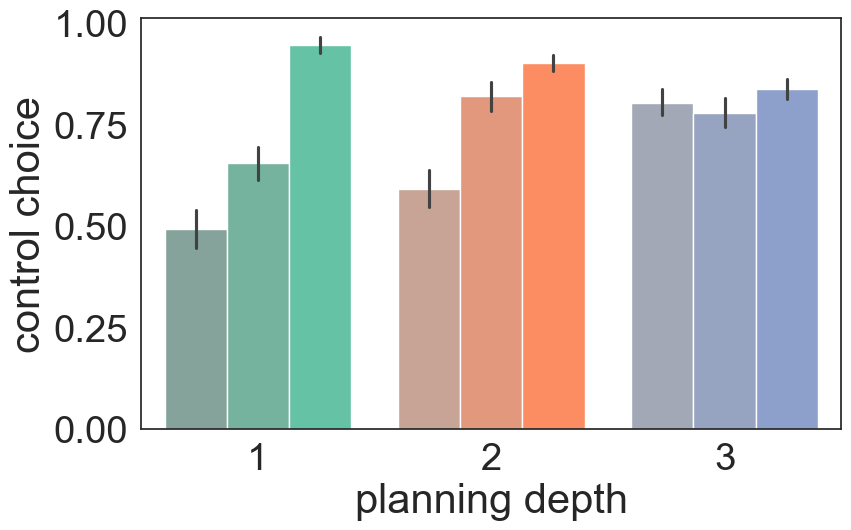

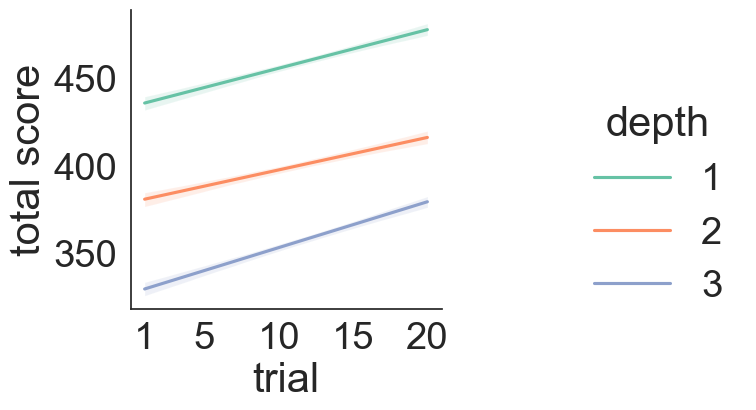

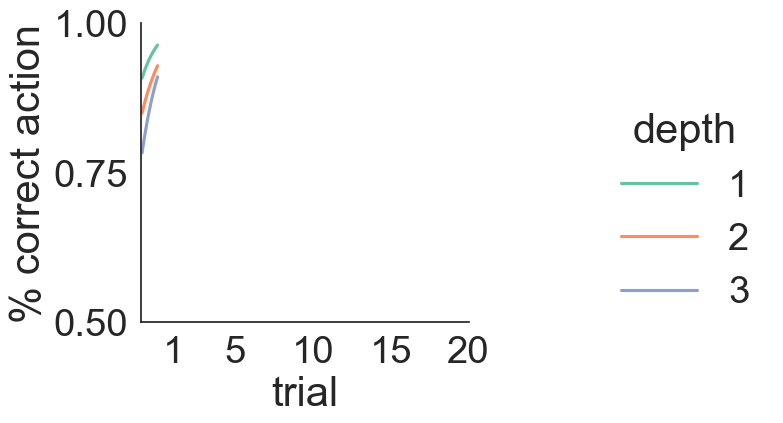

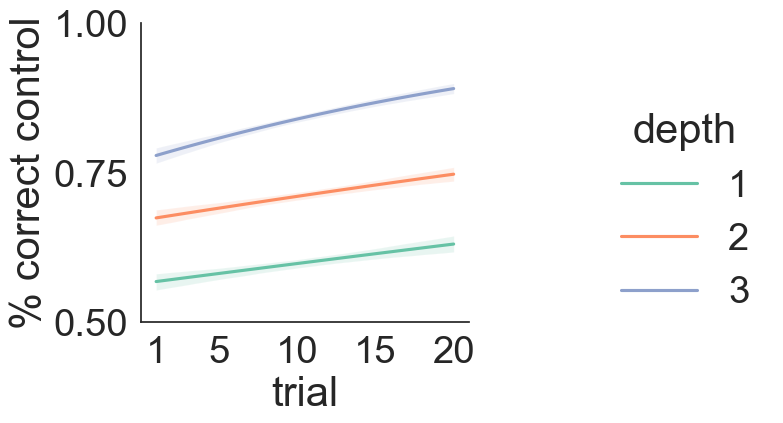

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple


sns.set(style='white', palette='mako', font_scale=2.5, rc=None)

# ---------------------------------------------
# 1) Compute per-subject means for EACH
#    (planning_depth × decision) combination
# ---------------------------------------------
sub_means = (
    df_results2
    .groupby(['sub','planning_depth','decision'])['control taking']
    .mean()
    .reset_index()
)
print(sub_means)

# ---------------------------------------------
# 2) Compute group means (bars)
# ---------------------------------------------
group_means = (
    sub_means
    .groupby(['sub','planning_depth','decision'])['control taking']
    .mean()
    .reset_index()
)



# ---------------------------------------------
# 4) Plot bars using subject-level group means
# ---------------------------------------------
plt.figure(figsize=(9,6))
ax = sns.barplot(
    data=sub_means,
    x="planning_depth",
    y="control taking",
    hue="decision",
    palette="Set2",
    ci=68            # IMPORTANT: we supply our own CIs
)

# ---------------------------------------------
# 5) Apply your custom desaturation logic
# ---------------------------------------------
for bar_group, desaturate_value in zip(ax.containers, [0.33,0.667,1]):
    for bar, color in zip(bar_group, plt.cm.Set2.colors):
        bar.set_facecolor(sns.desaturate(color, desaturate_value))

# ---------------------------------------------
# 6) Add custom bootstrap error bars
# ---------------------------------------------
# Get x locations for error bars
# (one per bar, in the order seaborn plots them)
x_positions = []
heights = []

for container in ax.containers:
    for bar in container:
        x_positions.append(bar.get_x() + bar.get_width()/2)
        heights.append(bar.get_height())

# convert to arrays
x_positions = np.array(x_positions)
heights = np.array(heights)

# # align heights & CIs: group_means is plotted in EXACT same order
# ax.errorbar(
#     x_positions,
#     heights,
#     yerr=[heights - lower, upper - heights],
#     fmt="none",
#     ecolor="black",
#     capsize=4,
#     lw=1.2,
#     zorder=10
# )

# ---------------------------------------------
# 7) Labels & cleanup
# ---------------------------------------------
ax.set(xlabel='planning depth')
ax.set(ylabel='control choice')

# remove legends if you want
plt.legend([],[], frameon=False)

plt.tight_layout()
plt.savefig('optimal_controlactualparticipantsempiricaldata.png',dpi=300)
plt.show()


from matplotlib.legend_handler import HandlerTuple


sns.set(style='white', palette='Set2', font_scale=2.5, rc=None)

# df_results2['decision']=timepoints_tracker
# df_results2['control taking']=decisions_lamp+decisions_zebra+decisions_cat
# df_results2['planning depth']=['depth=1']*(num_decisions_to_consider*3*len(subs))+['depth=2']*(num_decisions_to_consider*3*len(subs))+['depth=3']*(num_decisions_to_consider*3*len(subs))
import seaborn as sns
import matplotlib.pyplot as plt


# Assuming df and df_results2 are already defined properly
df_results2['trial'] = df_results2['trial_num_within_goal']
df_results2['total score'] = df['total_score'] * 100

# Create the lmplot
ax = sns.lmplot(
    x="trial", 
    y="total score", 
    hue='planning_depth', 
    palette='Set2', 
    ci=68, 
    scatter=False, 
    data=df_results2,
    height=4.8,
    aspect=1.2
)

# Customize ticks and labels
ax.axes[0, 0].set_xticks([1, 5, 10, 15, 20])
ax.set(xlabel='trial')

# Move and style the legend outside the plot
# ax._legend.set_bbox_to_anchor((1.05, 0.5))
ax._legend.set_frame_on(False)
ax._legend.set_title("depth")

# Retrieve the underlying Figure object and adjust layout manually
fig = ax.fig

# Save the figure by including the legend in the bounding box calculation
fig.savefig('total_score_plot.png', bbox_inches='tight', bbox_extra_artists=(ax._legend,))

plt.show()


ax = sns.lmplot(x="trial_num", y="correct_control_action", hue='planning_depth',scatter=False,
                logistic=True, palette='Set2', ci=68,height=4.8, aspect=1.2, data=df_results2)

# Access the underlying axes and set the ticks
ax.axes[0, 0].set_xticks([1, 5, 10, 15, 20])
ax.axes[0, 0].set_yticks([0.5,0.75,1])

ax.set_axis_labels('trial', '% correct action')
ax._legend.set_frame_on(False)
ax._legend.set_title("depth")

# Retrieve the underlying Figure object and adjust layout manually
fig = ax.fig

# Save the figure by including the legend in the bounding box calculation
fig.savefig('optimal_action_choice.png', bbox_inches='tight', bbox_extra_artists=(ax._legend,))

plt.show()

ax = sns.lmplot(x="trial", y="metacontrol_accuracy", hue='planning_depth',scatter=False,
                logistic=True, palette='Set2', ci=68, height=4.8, aspect=1.2,data=df_results2)

# Access the underlying axes and set the ticks
ax.axes[0, 0].set_xticks([1, 5, 10, 15, 20])
ax.axes[0, 0].set_yticks([0.5,0.75,1])

ax.set_axis_labels('trial', '% correct control')
ax._legend.set_frame_on(False)
ax._legend.set_title("depth")

# Retrieve the underlying Figure object and adjust layout manually
fig = ax.fig

# Save the figure by including the legend in the bounding box calculation
fig.savefig('optimal_metacontrol_choice.png', bbox_inches='tight', bbox_extra_artists=(ax._legend,))

plt.show()



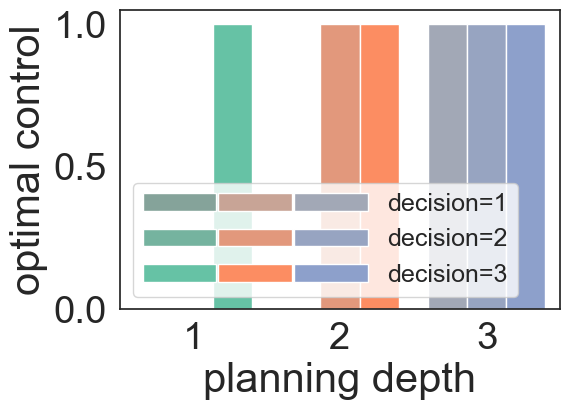

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

data = {
    "planning depth": [1, 1, 1, 2, 2, 2, 3, 3, 3],
    "decision": [1, 2, 3, 1, 2, 3, 1, 2, 3],
    "optimal control": [0, 0, 1, 0, 1, 1, 1, 1, 1]
}

dfp = pd.DataFrame(data)


# Plotting the barplot with the modified data
sns.set(style='white', font_scale=2.5, palette='Set2')
ax = sns.barplot(x="planning depth", y="optimal control", hue="decision",data=dfp)
for bar_group, desaturate_value in zip(ax.containers, [0.33,0.667,1]):
        for bar, color in zip(bar_group, plt.cm.Set2.colors):
            bar.set_facecolor(sns.desaturate(color, desaturate_value))
labels=[bar_group.get_label() for bar_group in ax.containers]
ax.legend(handles=[tuple(bar_group) for bar_group in ax.containers],loc='lower left',
    labels=['decision=1' if '0' in str(x) else 'decision=2' if '1' in str(x) else 'decision=3' for x in labels],
    prop={'size': 18},
    handlelength=9, handler_map={tuple: HandlerTuple(ndivide=None, pad=0.1)})




# Saving the plot
plt.tight_layout()
plt.savefig('simulated_optimal_Control_by_planningdepth.png', dpi=300)
plt.show()



/opt/miniconda3/envs/delayed-planning/lib/python3.13/site-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


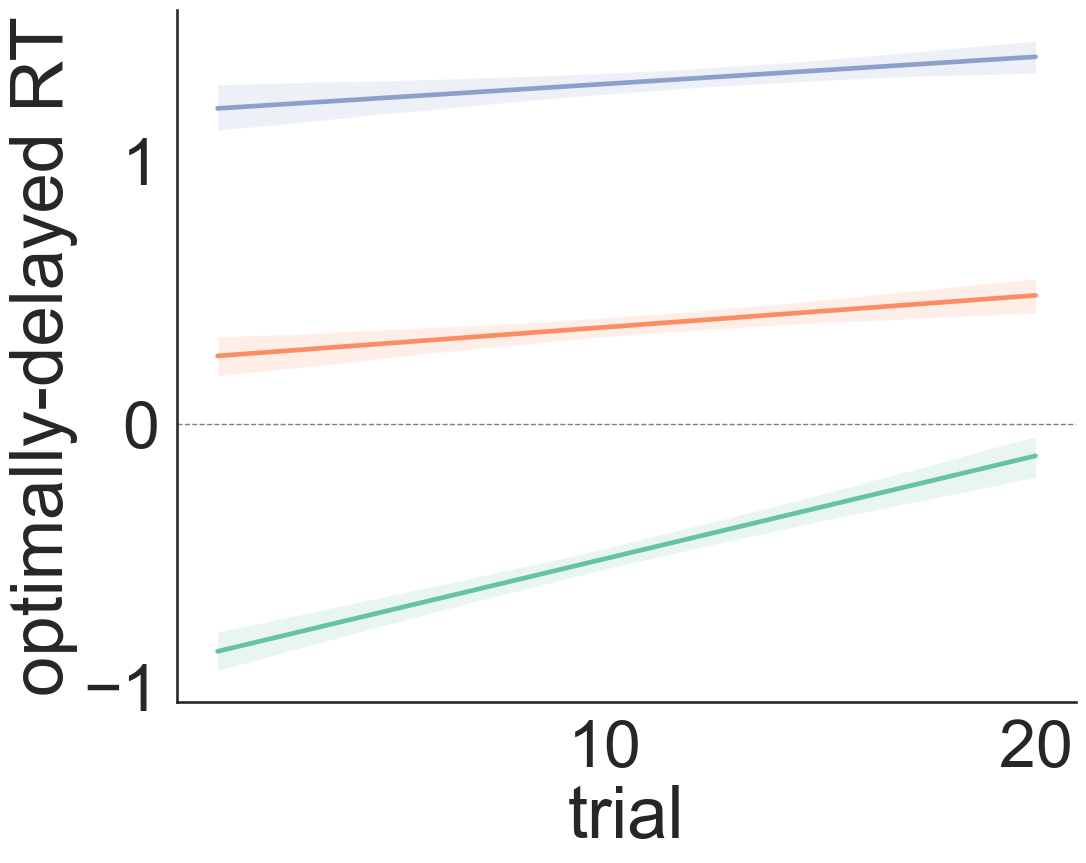

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 0) STARTING POINT: 'df' already in memory
# ---------------------------------------------------------------------
# Columns assumed:
#   sub | optimally_delayed | RT | decision (1–3) | trial_num_within_goal | planning_depth (1/2/3)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 0) STARTING POINT: 'df' already in memory
# ---------------------------------------------------------------------
# Columns assumed:
#   sub | optimally_delayed | RT | decision (1–3) | trial_num_within_goal | planning_depth (1/2/3)

# ---- (A) Keep only participants whose mean optimally_delayed > 0.4 ----
subs_to_keep = (df.groupby('sub')['optimally_delayed']
                  .mean()
                  .loc[lambda m: m > 0.4]
                  .index)
dfa = df[df['sub'].isin(subs_to_keep)]

# ---- (B) Keep valid rows ----
df_filt = dfa[dfa['optimally_delayed'] > -1].copy()

# ---- (C) Z-score RT within participant ----
df_filt['RT_z'] = df_filt.groupby('sub')['RT'] \
                         .transform(lambda x: (x - x.mean()) / x.std(ddof=0))

# ---- (D) Pivot wide: one row = sub × trial × depth, columns d1/d2/d3 ----
rt_wide = (df_filt
           .pivot_table(index=['sub', 'trial_num_within_goal', 'planning_depth'],
                        columns='decision', values='RT_z', aggfunc='mean')
           .rename(columns={1: 'd1', 2: 'd2', 3: 'd3'})
           .dropna())

# ---- (E) Compute signature strength ----
def signature(row):
    depth = row.name[2]
    if depth == 3:
        return row['d1'] - row[['d2', 'd3']].mean()
    elif depth == 2:
        return row['d2'] - row[['d1', 'd3']].mean()
    else:  # depth == 1
        return row['d3'] - row[['d1', 'd2']].mean()

rt_wide['signature'] = rt_wide.apply(signature, axis=1)

# ---- (F) Plot regression lines (no grid, no legend) ----
sns.set(style='white', context='talk',font_scale=2.9)        # <-- no grids

g = sns.lmplot(
        data   = rt_wide.reset_index(),
        x      = 'trial_num_within_goal',
        y      = 'signature',
        hue    = 'planning_depth',
        ci     = 68,
        palette='Set2',
        scatter=False,
        height = 10, aspect=0.7,
        markers='', legend_out=True
    )
g._legend.remove()                           # <-- remove legend


plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.xlabel('trial')
plt.ylabel('optimally-delayed RT')
plt.tight_layout()


plt.savefig('optimal_RT_overtime_scatter.png',dpi=300,bbox_inches='tight')

plt.show()


In [6]:
print(len(df['sub'].unique()))

81


Starting experiments...
Running No MC...
Running Cache All Once...
Running Cache MC + Replan...
Running Always Plan...


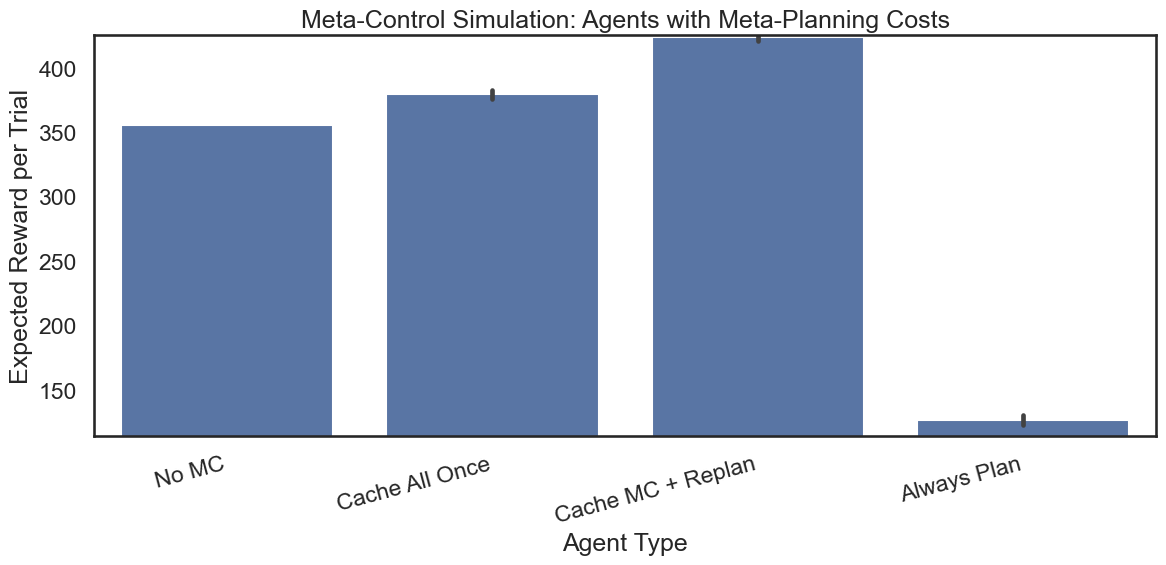


=== Summary Statistics ===
                     mean   std
agent                          
Always Plan        126.85  6.38
Cache All Once     379.34  6.09
Cache MC + Replan  423.71  5.67
No MC              355.39  0.35

=== By Depth (for reference) ===
depth                  1      2      3
agent                                 
Always Plan        126.8  126.8  126.8
Cache All Once     379.3  379.3  379.3
Cache MC + Replan  423.7  423.7  423.7
No MC              355.4  355.4  355.4

=== Agent Descriptions ===
Never Relinquish: Plans immediately, caches plans between trials
Cache Once: Meta-plans once per goal, caches all routes and timing
MBMC: Meta-plans once per goal, replans routes each trial
Always Replan: Meta-plans and plans all routes every single trial


In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from random import sample, seed

# ----------------------------
# Cost helpers
# ----------------------------
def compute_cost_planning(decision_step, cost_p):
    """Cost of planning at a given decision step"""
    if decision_step == 1:
        multiplier =  1# 8 * 3
    elif decision_step == 2:
        multiplier = 2  # 4 * 2
    else:
        multiplier = 1  # 2 * 1 
        
    return multiplier * cost_p

def compute_cost_maintenance(length, cost_m):
    """Cost of maintaining cached content"""
    return length * cost_m

def compute_cost_retrieve_cache(decision_step, cost_r):
    """Cost of retrieving cached plans"""
    return (3-decision_step) * cost_r

def compute_cost_meta_planning(num_routes, cost_mp):
    """Cost of meta-planning: determining when to take vs relinquish control
    
    This involves analyzing all possible routes to determine optimal initiation point.
    Cost scales with number of routes to consider.
    """
    return num_routes * cost_mp * 3

def pick_plan_matching_branch(plans, branch_sig):
    """Find a plan that matches the current branch signature"""
    k = len(branch_sig)
    for p in plans:
        if p[:k] == list(branch_sig):
            return p
    return None

# ----------------------------
# Simulation with Global Costs
# ----------------------------
def simulate_with_global_costs(
    trials=10000,
    engage_metacontrol=1,
    cache_everything=1,
    always_replan=0,  # New parameter for "Always Replan" agent
    rng_seed=None,
    reward_goal=400,
    reward_relinquish=100,
    cost_planning=15,
    cost_maintenance=5,
    cost_retrieve_cache=5,
    cost_meta_planning=15,  # New parameter for meta-planning cost
    mismatch_penalty=1
):
    """
    Maintenance costs are paid EVERY trial for ALL cached content,
    regardless of which goal is selected.
    
    Meta-planning costs are paid when determining optimal initiation points.
    """
    if rng_seed is not None:
        seed(rng_seed)
        np.random.seed(rng_seed)

    cached_plans = {'cat': [], 'zebra': [], 'lamp': []}
    cached_meta_control = {}
    last_branch_sig = {}

    possible_plans = {
        'cat':   [[1,2,2]],                         # depth 3, 1 route
        'zebra': [[1,1,2],[2,2,2]],                 # depth 2, 2 routes
        'lamp':  [[1,1,1],[1,2,1],[2,1,2],[2,2,1]]  # depth 1, 4 routes
    }

    

    # 0-based initiation for code; (cat=0,zebra=1,lamp=2)
    starting_planning = {'cat': 0, 'zebra': 1, 'lamp': 2}
    goals = ['cat','lamp','zebra']

    # Track total reward across all trials
    total_reward = 0
    counts_by_goal = {g: 0 for g in goals}

    for trial_num in range(trials):
        goal = sample(goals, 1)[0]
        counts_by_goal[goal] += 1

        # Temporary within-trial memory for "Always Replan" agent
        trial_temp_plans = []
        trial_temp_meta_control = None

        # For MC agents, initiation index (0,1,2). No_MC uses 0 (plans immediately).
        init_pt = starting_planning[goal] if engage_metacontrol == 1 else 0

        current_branch = []

        # "Always Replan" agent: meta-plan at start of every trial
        if always_replan == 1:
            # Pay meta-planning cost to determine when to take control
            num_routes = 8
            total_reward -= compute_cost_meta_planning(num_routes, cost_planning)
            
            # Plan all possible routes and store in temporary trial memory
            trial_temp_plans = list(possible_plans[goal])
            trial_temp_meta_control = [0,0,0]
            trial_temp_meta_control[init_pt] = 1

        for decision in range(3):  # 0,1,2 (maps to Decisions 1,2,3 in the write-up)
            if engage_metacontrol == 1:
                
                    
                if decision < init_pt:
                    # "Always Replan" pays within-trial maintenance for temporary memory
                    
      
                    if not always_replan:
                        if goal not in cached_meta_control:
                            num_routes = 7
                            total_reward -= compute_cost_meta_planning(num_routes, cost_planning)
    
                            # Pay planning cost and cache all routes
                            cached_meta_control[goal] = [0,0,0]
                            cached_meta_control[goal][init_pt] = 1
                            
                            if cache_everything == 1:
                                cached_plans[goal].extend(possible_plans[goal])
                                last_branch_sig[goal] = tuple(current_branch)
    
                            plan = pick_plan_matching_branch(possible_plans[goal], tuple(current_branch))
                            if plan is None and possible_plans[goal]:
                                plan = possible_plans[goal][0]
        
                    coin = np.random.choice([1,2])
                    current_branch.append(coin)
                  
                    total_reward += reward_relinquish
       
                    continue

                if decision == init_pt:
                    # Plan or retrieve at initiation
                    if always_replan == 1:
                        # "Always Replan": retrieve from within-trial temporary memory
                        base = compute_cost_retrieve_cache(decision, cost_retrieve_cache)
                        total_reward -= base
                        
                   
                    else:
                            
                        if goal in cached_meta_control:
                            # Goal has been encountered before
                            if cache_everything:
                                base = compute_cost_retrieve_cache(decision, cost_retrieve_cache)
                                extra = 0
                                prev_sig = last_branch_sig.get(goal)
                                if (prev_sig is not None) and (tuple(current_branch) != tuple(prev_sig)):
                                    extra = 0
                                total_reward -= (base + extra)
    
                                plan = pick_plan_matching_branch(cached_plans[goal], tuple(current_branch))
                                if plan is None and cached_plans[goal]:
                                    plan = cached_plans[goal][0]
    
                                last_branch_sig[goal] = tuple(current_branch)
                            else:
                                # MBMC (Replan agent): pays planning cost each time; no mismatch penalty
                                total_reward -= compute_cost_planning(decision, cost_planning)
                                
                        else:
                            # First encounter: compile & cache policy timing
                            # Pay meta-planning cost to determine initiation point
                            num_routes = 7
                            total_reward -= compute_cost_meta_planning(num_routes, cost_planning)
    
                            base = compute_cost_retrieve_cache(decision, cost_retrieve_cache)
                            total_reward -= base
                            
                            
                            # Pay planning cost and cache all routes
                            cached_meta_control[goal] = [0,0,0]
                            cached_meta_control[goal][init_pt] = 1
                            
                            if cache_everything == 1:
                                cached_plans[goal].extend(possible_plans[goal])
                                last_branch_sig[goal] = tuple(current_branch)
    
                      
                if decision == 2:
                    # Execute + maintenance
           
                    total_reward += reward_goal
                
                    # ---- GLOBAL MAINTENANCE COST ----
                    # Pay for ALL cached content across trials (not within-trial temp memory)
                    if cache_everything and not always_replan:
                        # Count all cached plans (from initiation onward)
                        post_init_len = 0
                        for g in goals:
                            g_init = starting_planning[g]
                            for p in cached_plans[g]:
                                keep = max(0, len(p) - g_init)
                                post_init_len += keep
                        plan_len = post_init_len
                    else:
                        # MBMC or Always Replan: no plans cached between trials
                        plan_len = 0
                

                    # Count all cached metacontrol policies (3 per goal)
                    # Always Replan doesn't cache between trials
                    if not always_replan:
                        mc_len = sum(len(cached_meta_control.get(g, [])) for g in goals)
                    else:
                        mc_len = 0

             
                    total_reward -= compute_cost_maintenance(plan_len, cost_maintenance)
                    total_reward -= compute_cost_maintenance(mc_len, cost_maintenance)
                

            else:
                # -------- No meta-control agent (Never Relinquish) --------
                if len(cached_plans[goal]) < 1 and decision == 0:
                    total_reward -= compute_cost_planning(decision, cost_planning)
                    actual_plan = sample(possible_plans[goal], 1)[0]
                    cached_plans[goal].append(actual_plan)

                if decision == 2:
                    total_reward += reward_goal
                    # Maintains all cached plans (3 steps each) - GLOBAL cost
                    total_plan_len = sum(len(cached_plans[g]) * 3 for g in goals)
                    total_reward -= compute_cost_maintenance(total_plan_len, cost_maintenance)

    return total_reward, counts_by_goal


def run_experiments(trials=100, reps=10):
    agents = [
        {"name": "No MC", "engage_metacontrol": 0, "cache_everything": 0, "always_replan": 0},
        {"name": "Cache All Once",       "engage_metacontrol": 1, "cache_everything": 1, "always_replan": 0},
        {"name": "Cache MC + Replan",             "engage_metacontrol": 1, "cache_everything": 0, "always_replan": 0},
        {"name": "Always Plan",    "engage_metacontrol": 1, "cache_everything": 0, "always_replan": 1},
    ]
    rows = []
    base_seed = 1345

    for agent in agents:
        print(f"Running {agent['name']}...")
        for r in range(reps):
            total_reward, counts_by_goal = simulate_with_global_costs(
                trials=trials,
                engage_metacontrol=agent["engage_metacontrol"],
                cache_everything=agent["cache_everything"],
                always_replan=agent["always_replan"],
                rng_seed=base_seed + 101 * r
            )
            # Calculate expected reward per trial
            exp_reward = total_reward / trials
            
            # Also track per-goal for reference
            for goal in counts_by_goal:
                rows.append({
                    "agent": agent["name"],
                    "rep": r + 1,
                    "goal": goal,
                    "expected_reward_per_trial": exp_reward,
                    "goal_count": counts_by_goal[goal]
                })

    df = pd.DataFrame(rows)
    # Map goal → planning depth
    depth_map = {"cat": 3, "zebra": 2, "lamp": 1}
    df["depth"] = df["goal"].map(depth_map)
    return df

# ---------- Run & Plot ----------
print("Starting experiments...")
dfa = run_experiments()

# Average across goals and reps to get overall performance
df_summary = dfa.groupby(['agent', 'rep'])['expected_reward_per_trial'].first().reset_index()

sns.set_context("talk")
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=df_summary,
    x="agent",
    y="expected_reward_per_trial",
    order=["No MC", "Cache All Once", "Cache MC + Replan", "Always Plan"]
)
ax.set_xlabel("Agent Type")
ax.set_ylabel("Expected Reward per Trial")
ax.set_ylim([114,425])

ax.set_title("Meta-Control Simulation: Agents with Meta-Planning Costs")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('simulation_with_metaplanning.png', dpi=300)
plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
print(df_summary.groupby('agent')['expected_reward_per_trial'].agg(['mean', 'std']).round(2))

# Also show by depth
print("\n=== By Depth (for reference) ===")
print(dfa.pivot_table(
    index="agent", 
    columns="depth",
    values="expected_reward_per_trial", 
    aggfunc="mean"
).round(1))

print("\n=== Agent Descriptions ===")
print("Never Relinquish: Plans immediately, caches plans between trials")
print("Cache Once: Meta-plans once per goal, caches all routes and timing")
print("MBMC: Meta-plans once per goal, replans routes each trial")
print("Always Replan: Meta-plans and plans all routes every single trial")

T-statistic: -11.820
P-value: 0.00000


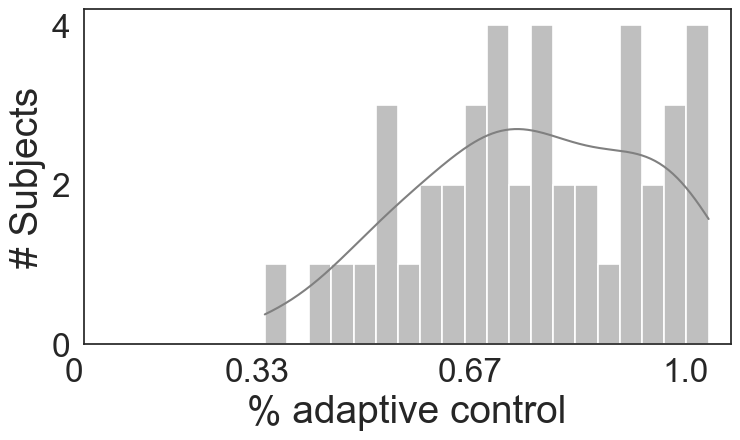

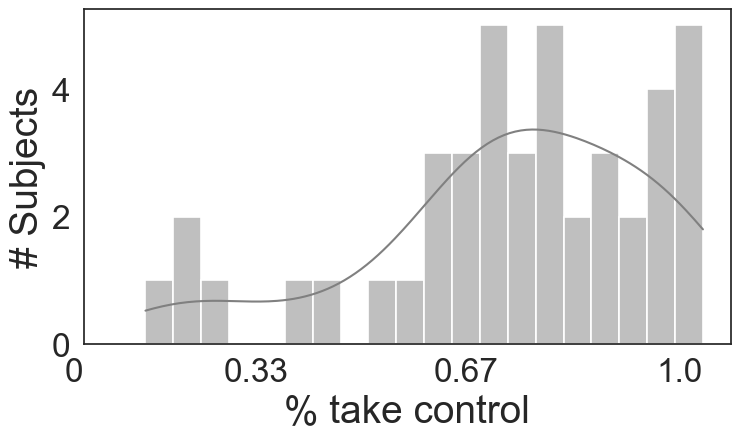


Number of subjects in each performance group:
control
Low     13140
High     1440
Name: count, dtype: int64
2.7574256546420854

Trial-level '2nd-A' counts after merge: 
2nd-A
< median    7380
> median    7200
Name: count, dtype: int64
Index(['Unnamed: 0', 'sub', 'trial_num', 'trial_num_within_goal', 'decision',
       'got_to_goal', 'got_to_goal_last', 'goal_switch', 'control_regressor',
       'RT', 'eligible_decisions_accuracy', 'retrieved_cached',
       'planning_depth', 'delayed_planning', 'worry', 'optimally_delayed',
       'optimally_control_choice', 'optimally_delayed_last', 'choice_numeric',
       'choices_numeric', 'choice_numeric_last',
       'interaction_won_and_metachoice', 'MB_decision',
       'optimal_metacontrol_choice', 'over_planning', 'over_control',
       'optimal_metacontrol_choice_last', 'points_from_choice',
       'points_from_goal', 'trial_points', 'total_points',
       'correct_control_action', 'space_hit_points', 'goal_points',
       'space_hit_points

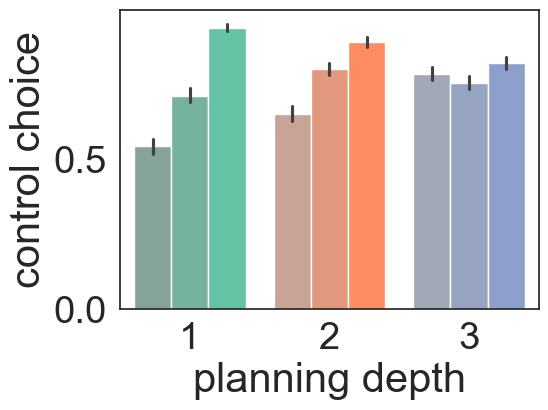

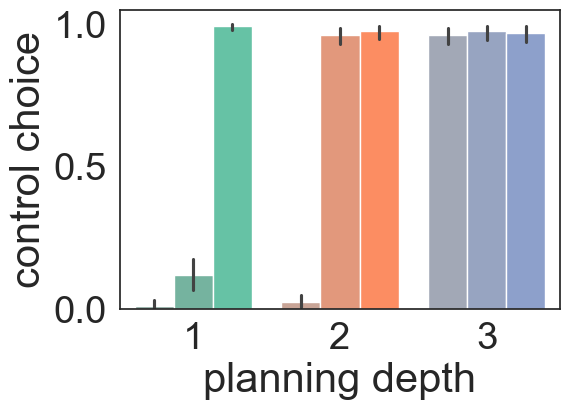

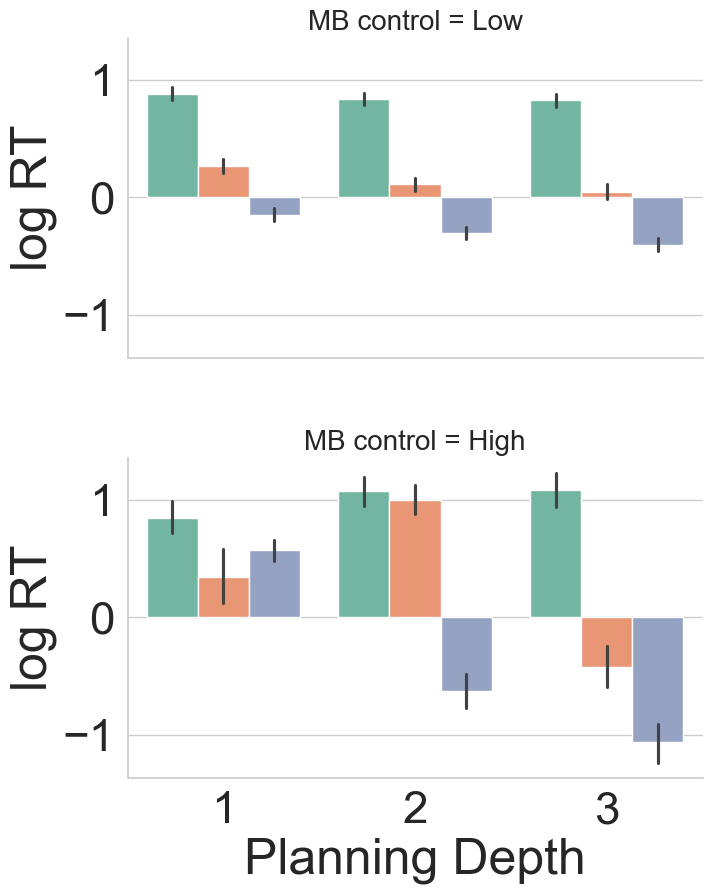

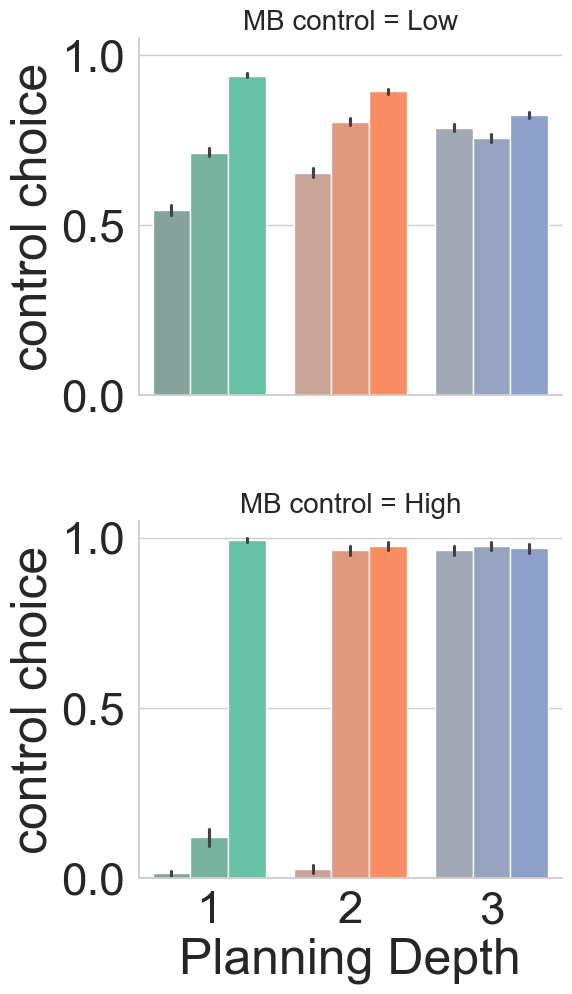

In [8]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


# --- Main script ---
sns.set(style='white', font_scale=2.2, palette='Set2')

# Create and process the data
# df = create_synthetic_data()
df_results2 = df.copy()
df_results2['rawRT'] = np.exp(df_results2['RT'])

# Filter subjects by optimality, as in the original script
subject_means = df_results2.groupby('sub')['optimally_delayed'].transform('mean')

# Further filter for later trials

# Prepare columns for plotting
df_results2['D1'] = (df_results2['decision'] == 1).astype(int)
df_results2['planning depth'] = df_results2['planning_depth']



# Per-subject means, rounded to 2 decimals
subject_means = (
    df_results2
    .groupby('sub', as_index=False)['optimal_metacontrol_choice']
    .mean()
)

# Count subjects per rounded mean (with stable, explicit column names)
count_data = (
    subject_means['optimal_metacontrol_choice'].round(2)
    .value_counts(sort=False)                       # don't auto-sort by frequency
    .rename_axis('% adaptive control')          # this becomes the x column name
    .reset_index(name='count')                      # this becomes the y column name
    .sort_values('% adaptive control')          # numeric ascending on x
)

# ---- One-sample t-test against null = 0.33 ----
t_stat, p_val = stats.ttest_1samp(subject_means['optimal_metacontrol_choice'], 0.90)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.5f}")
# print(f"Mean choice_numeric: {subject_means['choice_numeric'].mean():.3f}")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# --- Combined histogram (bars) + KDE curve ---
sns.histplot(
    data=count_data,
    x='% adaptive control',
    bins=20,              # adjust this for smoother or coarser bars
    color='gray',
    alpha=0.5,
    stat='count',
    kde=True,             # overlay KDE automatically
    linewidth=1.2
)

# --- Axis formatting ---
plt.xlabel('% adaptive control', fontsize=28)
plt.ylabel('# Subjects', fontsize=28)

# Only show selected x-axis tick labels (actual numeric positions)
plt.xticks(
    [0, 0.33, 0.67,1],
    ['0', '0.33','0.67','1.0'],
    ha='right',
    fontsize=24
)

plt.tight_layout()
plt.savefig('variability_metacontrol_kde.png', dpi=300, bbox_inches='tight')
plt.show()


# Per-subject means, rounded to 2 decimals
subject_means = (
    df_results2
    .groupby('sub', as_index=False)['control taking']
    .mean()
)

# Count subjects per rounded mean (with stable, explicit column names)
count_data = (
    subject_means['control taking'].round(2)
    .value_counts(sort=False)                       # don't auto-sort by frequency
    .rename_axis('% take control')          # this becomes the x column name
    .reset_index(name='count')                      # this becomes the y column name
    .sort_values('% take control')          # numeric ascending on x
)



plt.figure(figsize=(8, 5))

# --- Combined histogram (bars) + KDE curve ---
sns.histplot(
    data=count_data,
    x='% take control',
    bins=20,              # adjust this for smoother or coarser bars
    color='gray',
    alpha=0.5,
    stat='count',
    kde=True,             # overlay KDE automatically
    linewidth=1.2
)

# --- Axis formatting ---
plt.xlabel('% take control', fontsize=28)
plt.ylabel('# Subjects', fontsize=28)

# Only show selected x-axis tick labels (actual numeric positions)
plt.xticks(
    [0, 0.33, 0.67,1],
    ['0', '0.33','0.67','1.0'],
    ha='right',
    fontsize=24
)

plt.tight_layout()
plt.savefig('variability_control_taking.png', dpi=300, bbox_inches='tight')
plt.show()


# A sum of 3 means all 3 decisions in the trial were optimal (1 + 1 + 1 = 3).
s_performance = df_results2.groupby(['sub'])['optimal_metacontrol_choice'].mean().reset_index()

# Rename the new column for clarity
s_performance.rename(columns={'optimal_metacontrol_choice': 's_optimality_mean'}, inplace=True)

# 2. Create the 'perf' column based on the sum
s_performance['control'] = np.where(
    s_performance['s_optimality_mean'] > 0.92,
    'High', # All 3 decisions were optimal (sum == 3)
    'Low' # At least one decision was not optimal (sum < 3)
)

# Merge the performance group back into the main dataframe
df_results2 = pd.merge(
    df_results2, 
    s_performance[['sub', 'control']], 
    on=['sub'], # Use BOTH 'sub' AND 'trial_num' as keys
    how='left' # A left merge ensures no rows are lost from df_results2
)


print("\nNumber of subjects in each performance group:")
print(df_results2['control'].value_counts())


# --- NEW: Create Trial Phase Column (Pre vs. Post Trial 10) ---
df_results2['q'] = pd.qcut(
    df_results2['trial_num_within_goal'],
    q=2,
    labels=['1', '2']
)

df_results2=df_results2.reset_index(drop=True)
# --- Setup for Reproducibility (Replace with your actual data/imports if needed) ---
# Assuming 'df' is defined and has 'sub', 'decision', 'planning depth', 'got_to_goal'
# and the initial parameters setup is correct and subject indices align with 'sub' column
# params = { ... } (as defined in your prompt)
# df_results2 = df.copy() # Assuming this is correctly set up from your previous code

# --- 1. Create the new grouping variable '2nd-A' ---
# The params arrays are typically ordered by subject ID (0, 1, 2, ...).
# Assuming 'sub' in df_results2 is 0-indexed and sequential up to N-1 subjects.
params = {

    'MB_beta':        np.load('MB_B_exec.npy'),

    'forgetting': np.load('forget_exec.npy'),

    'MB_depth':       np.load('MB_depth_exec.npy'),

    'MB_breadth_A1':  np.load('MB_breadth_exec.npy') * 8,

    'MB_breadth_A2':  np.load('breadth2_exec.npy')   * 4,

    'rewardEffectCache':       np.load('cache_reward_exec.npy'),

    'cache':     np.load('mbcache_exec.npy'),

    'CB':             np.load('cb_exec.npy'),

    'repeat_control':             np.load('cache_plan_exec.npy'),

}


# Find the total number of subjects based on the length of the parameter arrays
num_subjects = len(params['MB_breadth_A2'])

# --- 2. Create the new grouping variable '2nd-A' at the SUBJECT level ---
# Now use the correct number of subjects based on the unique string IDs
mb_breadth_a2_values = params['MB_breadth_A2']
print(np.max(mb_breadth_a2_values))
# CRITICAL CHECK: Ensure your mb_breadth_a2_values array has the same length
# as the number of unique subjects. If not, you have a data mismatch.
if len(mb_breadth_a2_values) != num_subjects:
    raise ValueError(f"Parameter array length ({len(mb_breadth_a2_values)}) does not match "
                     f"number of unique subjects ({num_subjects}). Check data loading.")


second_a_group = np.where(mb_breadth_a2_values > np.median(mb_breadth_a2_values), '> median', '< median')

# Create a subject-level DataFrame using the *integer indices*
df_2nd_A = pd.DataFrame({
    'sub': df_results2['sub'].unique(), # The index (0, 1, 2, ...)
    '2nd-A': second_a_group
})


# --- 3. Merge the new grouping into the trial-level DataFrame (df_results2) ---
# Merge using the new integer 'sub_index' column, which matches df_2nd_A
df_results2 = pd.merge(
    df_results2,
    df_2nd_A,
    on='sub', # MERGE ON THE NEW INTEGER INDEX
    how='left'
)

second_a_group2 = np.where(mb_breadth_a2_values > 1.8, 'high', 'low')

# Create a subject-level DataFrame using the *integer indices*
df_2nd_A2 = pd.DataFrame({
    'sub': df_results2['sub'].unique(), # The index (0, 1, 2, ...)
    '2nd-A-best': second_a_group2
})


# --- 3. Merge the new grouping into the trial-level DataFrame (df_results2) ---
# Merge using the new integer 'sub_index' column, which matches df_2nd_A
df_results2 = pd.merge(
    df_results2,
    df_2nd_A2,
    on='sub', # MERGE ON THE NEW INTEGER INDEX
    how='left'
)

# df_results2=df_results2[df_results2['trial_num_within_goal']>16]
print(f"\nTrial-level '2nd-A' counts after merge: \n{df_results2['2nd-A'].value_counts()}")
# df_results2=df_results2[df_results2['trial_num_within_goal']>16]

df_results2['rawRT_z'] = df_results2.groupby('sub')['rawRT'].transform(
    lambda x: (x - x.mean()) / x.std()
)

df_results2['RT_z'] = df_results2.groupby('sub')['RT'].transform(
    lambda x: (x - x.mean()) / x.std()
)
print(df_results2.columns)
# df_results2=df_results2[df_results2['trial_num_within_goal']>5]
# Add median RT as a column (each row gets its group's median)
# df_results2=df_results2[df_results2['trial_num_within_goal']>19]
# df_results2['median_RT_group'] = df_results2.groupby(['sub', 'planning_depth', 'decision'])['rawRT'].transform('median')
# df_results2=df_results2[df_results2['rawRT']<10]


sns.set(style='white', palette='mako', font_scale=2.5, rc=None)

df_results3=df_results2[df_results2['control']=='Low']
# df_results2['control taking']=decisions_lamp+decisions_zebra+decisions_cat
# df_results2['planning depth']=['depth=1']*(num_decisions_to_consider*3*len(subs))+['depth=2']*(num_decisions_to_consider*3*len(subs))+['depth=3']*(num_decisions_to_consider*3*len(subs))
ax = sns.barplot(x="planning_depth", y="control taking", hue="decision",data=df_results3)
for bar_group, desaturate_value in zip(ax.containers, [0.33,0.667,1]):
		for bar, color in zip(bar_group, plt.cm.Set2.colors):
			bar.set_facecolor(sns.desaturate(color, desaturate_value))
ax.set(xlabel='planning depth')
ax.set(ylabel='control choice')

labels=[bar_group.get_label() for bar_group in ax.containers]
plt.legend([],[], frameon=False)

plt.tight_layout()
plt.savefig('optimal_controlactualparticipantsempiricaldata_low_performers.png',dpi=300)
plt.show()

# same panel for the top-decile participants (Fig. 2C, right)
plt.figure()
df_results3=df_results2[df_results2['control']=='High']
# df_results2['control taking']=decisions_lamp+decisions_zebra+decisions_cat
# df_results2['planning depth']=['depth=1']*(num_decisions_to_consider*3*len(subs))+['depth=2']*(num_decisions_to_consider*3*len(subs))+['depth=3']*(num_decisions_to_consider*3*len(subs))
ax = sns.barplot(x="planning_depth", y="control taking", hue="decision",data=df_results3)
for bar_group, desaturate_value in zip(ax.containers, [0.33,0.667,1]):
		for bar, color in zip(bar_group, plt.cm.Set2.colors):
			bar.set_facecolor(sns.desaturate(color, desaturate_value))
ax.set(xlabel='planning depth')
ax.set(ylabel='control choice')

labels=[bar_group.get_label() for bar_group in ax.containers]
plt.legend([],[], frameon=False)

plt.tight_layout()
plt.savefig('optimal_controlactualparticipantsempiricaldata_high_performers.png',dpi=300)
plt.show()


import seaborn as sns
import matplotlib.pyplot as plt

# --- Compute medians for each subject -> planning depth -> decision
median_rt = (
    df_results2
    .groupby(['sub', 'planning_depth', 'decision'])['rawRT']
    .median()
    .reset_index()
)

# --- Compute overall median (across subjects) for plotting
overall_medians = (
    median_rt
    .groupby(['planning_depth', 'decision'])['rawRT']
    .median()
    .reset_index()
)
sns.set(style='whitegrid', font_scale=3, palette='Set2')

# --- Create the catplot
# --- NEW: Create faceted plot using catplot with rows for performance and columns for trial phase ---
# --- Create faceted plot using catplot with rows for performance and columns for trial phase ---
g = sns.catplot(
    x="planning depth",
    y="RT",
    hue="decision",
    row="control",
    data=df_results2,
    kind="bar",
    palette='Set2',   # initial palette; we'll override colors manually below
    height=5,
    aspect=1.6,
    legend=False,
)

# Add median values as text annotations within each facet
for row_idx, row_val in enumerate(g.row_names):
    for col_idx, col_val in enumerate(g.col_names):
        ax = g.axes[row_idx, col_idx]
        
        # Filter data for this specific facet
        facet_data = df_results2[
            (df_results2['control'] == row_val) & 
            (df_results2['q'] == col_val)
        ]
        
        # Get y-axis limits to position text at bottom
        ylim = ax.get_ylim()
        y_pos = ylim[0] + (ylim[1] - ylim[0]) * 0.02  # 2% from bottom
        
        # Define offsets for each decision
        decision_offsets = {1: -0.2, 2: 0.0, 3: 0.2}
        
        # Loop through all planning depths and decisions
        for planning_depth in [1, 2, 3]:
            for decision, offset in decision_offsets.items():
                subset = facet_data[
                    (facet_data['planning depth'] == planning_depth) & 
                    (facet_data['decision'] == decision)
                ]
                if len(subset) > 0:
                    median_val = subset['RT'].median()
                    ax.text(planning_depth - 1 + offset, y_pos, f'{median_val:.2f}', 
                            ha='center', va='bottom', fontsize=14, color='black')

# --- Apply custom color: SAME base color per planning depth; saturation varies by decision ---
# Saturation map per decision (1→light, 2→medium, 3→full)
sat_map = {1: 0.33, 2: 0.67, 3: 1.00}

for ax in g.axes.flatten():
    # Clean up titles
    title = ax.get_title()
    new_title = title.replace('control', 'MB control')
    ax.set_title(new_title, fontsize=20)

    # Seaborn draws boxes grouped by x (planning depth) then hue (decision).
    # With 3 depths and 3 decisions: order is
    # depth=1(dec1,dec2,dec3), depth=2(dec1,dec2,dec3), depth=3(dec1,dec2,dec3)
    n_decisions = 3
    n_depths = 3

    # If this facet has no boxes, continue
    if len(ax.artists) == 0:
        ax.set_xlabel("Planning Depth")
        continue

    for i, artist in enumerate(ax.artists):
        depth_idx = i // n_decisions        # 0,1,2 → planning depth 1,2,3
        decision_idx = i % n_decisions      # 0,1,2 → decision 1,2,3

        planning_depth = depth_idx + 1
        decision = decision_idx + 1

        # Base color determined by planning depth (same hue within depth)
        base_color = plt.cm.Set2.colors[depth_idx % len(plt.cm.Set2.colors)]
        # Saturation determined by decision within that depth
        color = sns.desaturate(base_color, sat_map.get(decision, 1.0))

        artist.set_facecolor(color)
        artist.set_edgecolor(color)

        # Also recolor the corresponding whiskers/median/caps lines for this box
        # Each box has 6 associated Line2D objects, in order.
        start = i * 6
        end = start + 6
        if end <= len(ax.lines):
            for ln in ax.lines[start:end]:
                ln.set_color(color)

    ax.set_xlabel("Planning Depth")

# Set Y-axis label only for the left-most plots in each row
g.axes[0,0].set_ylabel("log RT")
if g.axes.shape[0] > 1:
    g.axes[1,0].set_ylabel("log RT")

# --- Final Touches ---
plt.savefig('Faceted_RTs_by_Performance_and_TrialPhase.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------
# --- 3. Second Plot: Using the '2nd-A' group ---
# ----------------------------------------------------------------------
df_results2['control choice']=(df_results2['choice_numeric']-1)*-1

# Use '2nd-A' for the row, and RT_z for the y-axis (as in the first plot)
g2 = sns.catplot(
    x="planning depth",
    y="control choice", # Using the standardized log(RT)
    hue="decision",
    row="control", # NEW GROUPING
    data=df_results2,
    kind="bar",
    palette='Set2',
    height=5.5,
    aspect=1.2,
    legend=False,
    errorbar=("ci", 68) # Use 68% CI for standard error visual
)

# --- Apply custom color desaturation (as per your original script) ---
# Assuming decision has 2 levels (D1 and D>1), we use 2 desaturation values
desaturation_values = [0.33,0.667,1]
colors = plt.cm.Set2.colors

for ax in g2.axes.flatten():
    title = ax.get_title()
    # Example title format: '2nd-A = something | half = X'
    new_title = title.replace('control', 'MB control')
    ax.set_title(new_title, fontsize=20)

    for bar_group_idx, bar_group in enumerate(ax.containers):
        desaturate_value = desaturation_values[bar_group_idx % len(desaturation_values)]
        for bar, color_index in zip(bar_group, range(len(bar_group))):
             # Use the colors cyclically from the Set2 palette
             color = colors[color_index % len(colors)]
             bar.set_facecolor(sns.desaturate(color, desaturate_value))

    ax.set_xlabel("Planning Depth")

# Set Y-axis label only for the left-most plots in each row
g2.axes[0,0].set_ylabel("control choice")
if g2.axes.shape[0] > 1:
    g2.axes[1,0].set_ylabel("control choice")

# --- Final Touches ---
plt.savefig('Faceted_CC_by_2ndA_and_GoalSuccess.png', dpi=300, bbox_inches='tight')
plt.show()

             sub  planning_depth  decision  medianRT
0    sub-001.csv               2         1   1.46130
1    sub-001.csv               2         2   1.32070
2    sub-001.csv               2         3   0.52300
3    sub-001.csv               3         1   0.99135
4    sub-001.csv               3         2   0.28675
..           ...             ...       ...       ...
397  sub-092.csv               3         2   0.68500
398  sub-092.csv               3         3   0.60600
399  sub-093.csv               2         1   2.93590
400  sub-093.csv               2         2   1.60925
401  sub-093.csv               2         3   0.52505

[402 rows x 4 columns]


/var/folders/8r/25hhbysn4fs9l8znzmnyhp580000gn/T/ipykernel_35151/1218553871.py:91: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(
/var/folders/8r/25hhbysn4fs9l8znzmnyhp580000gn/T/ipykernel_35151/1218553871.py:205: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle(


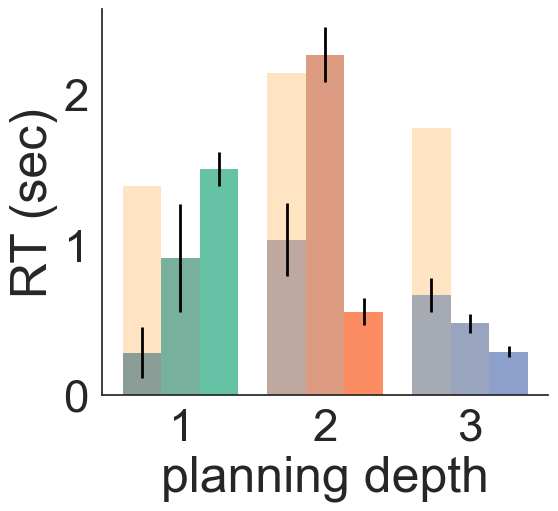

In [9]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

sns.set(style='white', font_scale=3)

# ---------- helper: bootstrap SE of the median -----------------
def bootstrap_median_se(data, n_boot=2000):
    """
    data: 1D array-like of values
    n_boot: number of bootstrap resamples
    Returns: (median, standard_error)
    """
    data = np.asarray(data)
    if data.size == 0:
        return np.nan, np.nan
    if data.size == 1:
        # no variability with 1 observation
        return np.median(data), np.nan

    boots = np.random.choice(data, size=(n_boot, data.size), replace=True)
    medians = np.median(boots, axis=1)
    se = medians.std(ddof=1)
    return np.median(data), se

# --- Data prep -------------------------------------------------

df_results3 = df.copy()

sub_od = df_results3.groupby('sub')['optimally_delayed'].mean()

df_results3 = df_results3[df_results3['got_to_goal'] == 1]
df_results3 = df_results3[df_results3['optimally_delayed'] == 1]
df_results3 = df_results3[df_results3['trial_num'] > -0.5]

# subject-wise median per (sub × planning_depth × decision)
df_results3 = (
    df_results3
    .groupby(['sub', 'planning_depth', 'decision'], as_index=False)
    .agg(medianRT=('rawRT', 'median'))
)
print(df_results3)

df_results3['RT (sec)'] = df_results3['medianRT']
df_results3['planning depth'] = df_results3['planning_depth']

# ---------- compute global Δ1 (using medians by decision) ------
# Δ1 = median(RT_decision1) - mean(median(RT_decision2), median(RT_decision3))
medians_dec = df_results3.groupby('decision')['RT (sec)'].median()

have_all_three = set([1, 2, 3]).issubset(medians_dec.index)
if have_all_three:
    RT1 = medians_dec.loc[1]
    RT2 = medians_dec.loc[2]
    RT3 = medians_dec.loc[3]
    delta1 = RT1 - ((RT2 + RT3) / 2.0)
else:
    delta1 = 0.0  # fallback (no Δ1 possible)

# ---------- bootstrap SE for each (planning depth, decision) ---
# For decision = 1, bootstrap on RT - Δ1, and use that median as the
# height for the error bar (subtracted value).
boot_rows = []
for (depth, dec), grp in df_results3.groupby(['planning depth', 'decision']):

    data_raw = grp['RT (sec)'].values

    if (dec == 1) and have_all_three:
        data_for_boot = data_raw - delta1
    else:
        data_for_boot = data_raw

    med, se = bootstrap_median_se(data_for_boot)

    boot_rows.append({
        'planning depth': depth,
        'decision': dec,
        'median_for_errorbar': med,  # this is where we place the error bar
        'se': se
    })

df_boot = pd.DataFrame(boot_rows)

# ensure consistent ordering for mapping bars -> groups
x_order = sorted(df_results3['planning depth'].unique())
hue_order = sorted(df_results3['decision'].unique())

# --- Barplot ---------------------------------------------------
g = sns.catplot(
    data=df_results3,
    x="planning depth",
    y="RT (sec)",
    hue="decision",
    kind="bar",
    estimator=np.median,
    palette='Set2',
    height=6,
    aspect=0.9,
    linewidth=0,
    order=x_order,
    ci=None,
    hue_order=hue_order,
)

# --- Custom desaturation scheme --------------------------------
base_colors = plt.cm.Set2.colors
desats = [0.2, 0.6, 1.0]

for ax in g.axes.flatten():
    if ax is None:
        continue
    for decision_idx, container in enumerate(ax.containers):
        if decision_idx >= len(desats):
            continue
        desat_val = desats[decision_idx]
        for bar, base_color in zip(container, base_colors):
            bar.set_facecolor(sns.desaturate(base_color, desat_val))

# ---------- overlay bootstrap SE error bars --------------------
for ax in g.axes.flatten():
    if ax is None:
        continue

    for decision_idx, container in enumerate(ax.containers):
        if decision_idx >= len(hue_order):
            continue
        dec = hue_order[decision_idx]

        for bar_idx, bar in enumerate(container):
            if bar_idx >= len(x_order):
                continue
            depth = x_order[bar_idx]

            # look up (median_for_errorbar, se) for this (depth, decision)
            sel = df_boot[
                (df_boot['planning depth'] == depth) &
                (df_boot['decision'] == dec)
            ]
            if sel.empty:
                continue

            se = sel['se'].iloc[0]
            if np.isnan(se):
                continue

            median_for_err = sel['median_for_errorbar'].iloc[0]

            # bar center
            x_center = bar.get_x() + bar.get_width() / 2.0

            # y-position for errorbar:
            #   - for dec != 1: this is just the original median (since
            #     data_for_boot = raw RT)
            #   - for dec == 1: this is the median of (RT - Δ1),
            #     i.e. the subtracted value as requested.
            y = median_for_err
            # if decision_idx==0:
            #     c_bar='firebrick'
            #     ax.errorbar(
            #     x_center,
            #     median_for_err+delta1,
            #     yerr=se,
            #     fmt='none',
            #     ecolor=c_bar,
            #     capsize=0,
            #     linewidth=2,
            #     zorder=15,
            # )
            
            c_bar='black'
            ax.errorbar(
                x_center,
                y,
                yerr=se,
                fmt='none',
                ecolor=c_bar,
                capsize=0,
                linewidth=2,
                zorder=15,
            )

# --- Add Δ1 rectangles on decision=1 bars ----------------------
if have_all_three:
    for ax in g.axes.flatten():
        if ax is None:
            continue

        # decision=1 bars
        if 1 in hue_order:
            container = ax.containers[hue_order.index(1)]

            for bar in container:
                bar_x = bar.get_x()
                bar_w = bar.get_width()
                bar_h = bar.get_height()

                rect_x = bar_x
                rect_w = bar_w
                rect_y = bar_h - delta1      # start Δ1 below bar top
                rect_h = delta1              # height = Δ1

                ax.add_patch(
                    plt.Rectangle(
                        (rect_x, rect_y),
                        rect_w,
                        rect_h,
                        color='bisque',
                        alpha=1,
                        edgecolor='none',
                        linewidth=0,
                        zorder=10
                    )
                )

# --- Build custom external legend ------------------------------
if g._legend is not None:
    g._legend.remove()

plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig(
    'RTs_D1_removed_secondhalf.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


14580
(0.544313725490196, 0.6164705882352941, 0.5937254901960785)
(0.7466666666666666, 0.659607843137255, 0.6258823529411766)
(0.6501960784313726, 0.6650980392156863, 0.6988235294117647)
(0.47215686274509794, 0.6886274509803921, 0.6203921568627451)
(0.8674509803921567, 0.6062745098039216, 0.5050980392156864)
(0.6015686274509804, 0.6462745098039215, 0.747450980392157)
(0.4, 0.7607843137254902, 0.6470588235294118)
(0.9882352941176471, 0.5529411764705883, 0.3843137254901961)
(0.5529411764705883, 0.6274509803921569, 0.796078431372549)


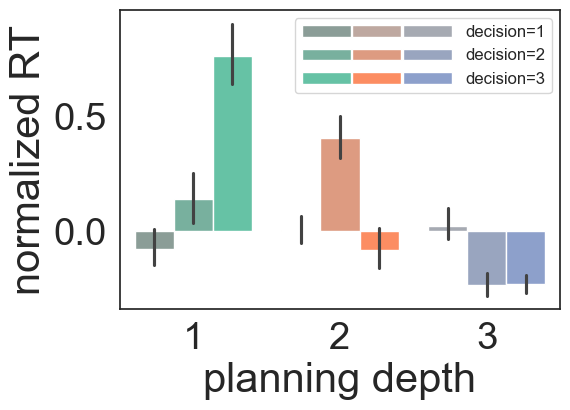

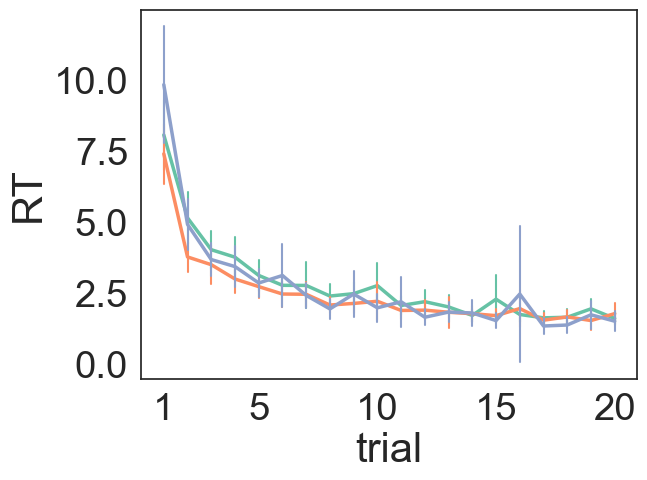

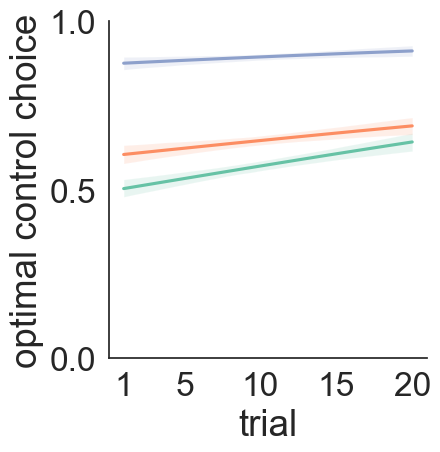

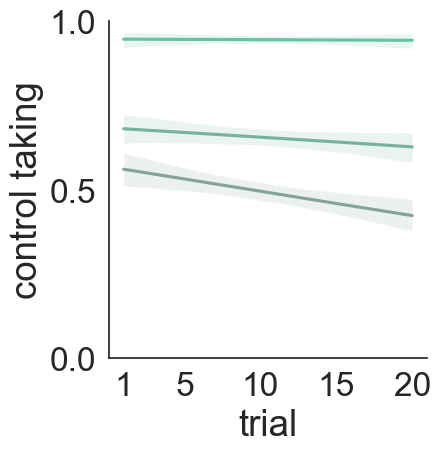

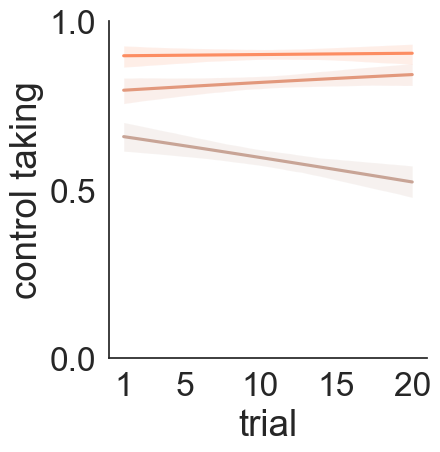

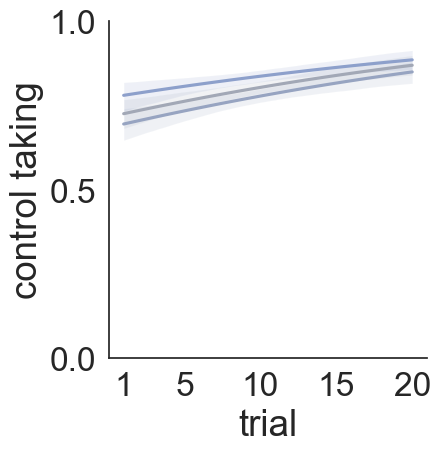

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple
from matplotlib.container import BarContainer

sns.set(style='white', font_scale=2.5, palette='Set2')

print(len(df))
df_result2=df.copy()

df_results2['RT'] = np.exp(df['RT'])

# df_results2=df_results2[df_results2['trial_num_within_goal']>10]
df_results2=df_results2[df_results2['optimally_delayed']==1]
df_results2=df_results2.reset_index(drop=True)

# df_results2['normalized RT'] = df_results2.groupby(['decision'])['RT'].transform(lambda x: (x - x.mean())/x.std())
# non_decision_time=1
# df_results2['normalized RT'] = [df_results2['RT'][i]-non_decision_time if df_results2['decision'][i]==1 else df_results2['RT'][i] for i in range(len(df_results2))]
df_results2['normalized RT']= df_results2.groupby(['decision'])['RT'].transform(lambda x: (x - x.mean())/x.std())

df_results2['planning depth'] = df_results2['planning_depth']
df_results2['trial number'] = df_results2['trial_num_within_goal']

ax = sns.barplot(x="planning depth", y="normalized RT", hue="decision", orient='v',palette='Set2',data=df_results2)
bar_containers=[c for c in ax.containers if isinstance(c, BarContainer)]
for bar_group, desaturate_value in zip(bar_containers, [0.2,0.6,1]):
        for bar, color in zip(bar_group, plt.cm.Set2.colors):
            x=sns.desaturate(color, desaturate_value)
            print(x)
            bar.set_facecolor(sns.desaturate(color, desaturate_value))
labels=[bar_group.get_label() for bar_group in bar_containers]
ax.legend(handles=[tuple(bar_group) for bar_group in bar_containers],loc='upper right',
    labels=[f'decision={i+1}' for i in range(len(bar_containers))],
    prop={'size': 12},
    handlelength=9, handler_map={tuple: HandlerTuple(ndivide=None, pad=0.1)})

# plt.legend([],[], frameon=False)

plt.tight_layout()
# plt.title('RT for optimally-delayed trials')
plt.savefig('optimal_planning_RTs.png',dpi=300,bbox_inches='tight')
plt.show()


sns.set(style='white', font_scale=2.5, palette='Set2')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Assuming df_results2 is already defined
df_results2=df.copy()
df_results2['RT'] = np.exp(df['RT'])
df_results2['planning depth'] = df_results2['planning_depth']
df_results2['trial'] = df_results2['trial_num_within_goal']

# plt.figure(figsize=(5, 5))


# Main plot
ax = sns.lineplot(x="trial", y="RT", hue='planning depth', err_style="bars",linewidth=2.5, errorbar=("se", 2),palette='Set2', data=df_results2)
ax.set_xticks([1,5,10,15,20])
ax.legend_.remove()  # Remove legend from inset
# plt.title('RT over time')

sns.set(style='white', font_scale=1.75, palette='Set2')

# Inset plot
# inset_ax = inset_axes(ax, width="20%", height="35%", loc='upper center', borderpad=1.5)
# inset_ax.set_xticks([1,2,3])

# # Filter data for the first 3 trials
# df_zoomed = df_results2[df_results2['trial'] <= 3]

# # Plot the zoomed-in data
# inset_ax = sns.lineplot(x="trial", y="RT", hue='planning depth', err_style="bars",linewidth=2.5, ci=68,palette='Set2', data=df_zoomed)
# inset_ax.set_title('Initial Trials')
# sns.move_legend(inset_ax, "upper left", bbox_to_anchor=(1.50, 3.50))

# Save the figure
plt.savefig('RTs_by_time_withOUT_inset.png', dpi=300,bbox_inches='tight')
plt.show()

sns.set(style='white', font_scale=1.5, palette='Set2')



# Assuming df_results2 is already defined
df_results2=df.copy()
df_results2['control taking']=(df['choice_numeric']-1)*-1
df_results2['RT'] = np.exp(df['RT'])
df_results2['planning depth'] = df_results2['planning_depth']
df_results2['trial'] = df_results2['trial_num_within_goal']
df_results2['optimally delayed'] = df_results2['optimally_delayed']

df_results2['optimal control choice']=df_results2['optimal_metacontrol_choice']




palette = sns.color_palette("Purples")

sns.set(style='white', font_scale=2.2, palette='Set2')

custom_palette1 = [ (0.5208627450980392, 0.6399215686274509, 0.602392156862745),
                  (0.460070588235294, 0.7007137254901961, 0.6248588235294118),
                  (0.4, 0.7607843137254902, 0.6470588235294118)]
custom_palette2 = [  (0.785921568627451, 0.6422745098039215, 0.5866274509803922),
(0.8876823529411766, 0.5973411764705883, 0.48486666666666656),
(0.9882352941176471, 0.5529411764705883, 0.3843137254901961)]
custom_palette3 = [
                  (0.6343921568627452, 0.6589803921568628, 0.7146274509803922),
(0.5934235294117648, 0.643121568627451, 0.7555960784313726),
(0.5529411764705883, 0.6274509803921569, 0.796078431372549)]
# Plot the lines on two facets

ax=sns.lmplot(
    data=df_results2,
    x="trial", y="optimal control choice",logistic=True,scatter=False,
    hue="decision", palette='Set2',legend=False)

for axs in ax.axes.flat: 
    axs.set_xticks([1, 5, 10, 15, 20])
    axs.set_yticks([0,0.5,1])
plt.savefig('controlTaking_by_time_depth2.png', dpi=300,bbox_inches='tight')

plt.show()
ax=sns.lmplot(
    data=df_results2[df_results2['planning_depth']==1],
    x="trial", y="control taking",scatter=False,
    hue="decision", palette=custom_palette1,logistic=True,legend=False)

for axs in ax.axes.flat: 
    axs.set_xticks([1, 5, 10, 15, 20]) 
    axs.set_yticks([0,0.5,1])
plt.savefig('controlTaking_by_time_depth1.png', dpi=300,bbox_inches='tight')

plt.show()

# Plot the lines on two facets
ax=sns.lmplot(
    data=df_results2[df_results2['planning_depth']==2],
    x="trial", y="control taking",logistic=True,scatter=False,
    hue="decision", palette=custom_palette2,legend=False)

for axs in ax.axes.flat: 
    axs.set_xticks([1, 5, 10, 15, 20])
    axs.set_yticks([0,0.5,1])
plt.savefig('controlTaking_by_time_depth2.png', dpi=300,bbox_inches='tight')

plt.show()

# Plot the lines on two facets
ax=sns.lmplot(
    data=df_results2[df_results2['planning_depth']==3],
    x="trial", y="control taking",logistic=True,scatter=False,
    hue="decision", palette=custom_palette3,legend=False)

for axs in ax.axes.flat: 
    axs.set_xticks([1, 5, 10, 15, 20])
    axs.set_yticks([0,0.5,1])
plt.savefig('controlTaking_by_time_depth3.png', dpi=300,bbox_inches='tight')

plt.show()
 


In [11]:
print((df['choice_numeric']-1)*-1)


0        1
1        1
2        1
3        1
4        1
        ..
14575    1
14576    0
14577    1
14578    1
14579    1
Name: choice_numeric, Length: 14580, dtype: int64


/var/folders/8r/25hhbysn4fs9l8znzmnyhp580000gn/T/ipykernel_35151/4008997389.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.lineplot(x='trial_num_within_goal',y='optimally_delayed',hue='planning_depth',ci=68,data=df1,palette='Set2')


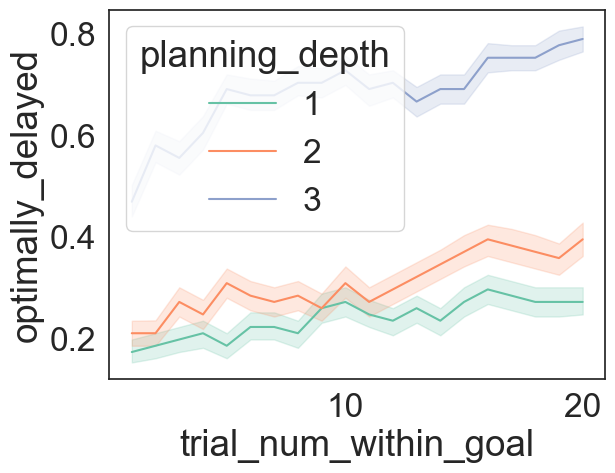

In [12]:
# df1=df[df['choice_numeric']==0]
df1=df
sns.lineplot(x='trial_num_within_goal',y='optimally_delayed',hue='planning_depth',ci=68,data=df1,palette='Set2')
# plt.savefig('accuracy_by_decision_onlycontrolchoices_bar.png',dpi=300)
plt.show()


In [13]:

# import pymc as pm
# import arviz as az
# import numpy as np
# import pandas as pd

# # Assuming 'df' is your DataFrame and is already loaded
# # Prepare data
# sub_idx, subs = pd.factorize(df['sub'])  # Convert subject IDs to indices for group-level parameters
# got_to_goal = df['got_to_goal'].values
# decision_eligible = (df['decision']-df['decision'].mean())/df['decision'].std()
# planning_depth = (df['planning_depth']-df['planning_depth'].mean())/df['planning_depth'].std()
# trial_num_v = df['trial_num']
# interaction=trial_num_v*decision_eligible
# opt_choice =

# with pm.Model() as model_optcontrol:
#     # Priors for fixed effects
#     intercept = pm.Normal('intercept', mu=0, sigma=5)
#     decision_coef = pm.Normal('decision_coef', mu=0, sigma=5)
#     pd_coef = pm.Normal('depth_coef', mu=0, sigma=5)
#     t_coef = pm.Normal('trial_coef', mu=0, sigma=5)
#     # i_coef = pm.Normal('interaction_coef', mu=0, sigma=5)
    
#     # Priors for random effects
#     sigma_sub = pm.HalfNormal('sigma_sub', 5.0)
#     intercept_sub = pm.Normal('intercept_sub', mu=0, sigma=sigma_sub, shape=len(subs))
    
#     sigma_slope_sub = pm.HalfNormal('sigma_slope_sub', 5.0)
#     decision_coef_sub = pm.Normal('slope_sub_decision', mu=0, sigma=sigma_slope_sub, shape=len(subs))

#     sigma_slope_pd = pm.HalfNormal('sigma_slope_pd', 5.0)
#     pd_coef_sub = pm.Normal('slope_sub_pd', mu=0, sigma=sigma_slope_pd, shape=len(subs))

#     sigma_slope_tn = pm.HalfNormal('sigma_slope_tn', 5)
#     slope_sub_tn = pm.Normal('slope_sub_tn', mu=0, sigma=sigma_slope_tn, shape=len(subs))

#     # sigma_slope_interaction = pm.HalfNormal('sigma_slope_interaction', 5)
#     # slope_sub_interaction = pm.Normal('slope_sub_interaction', mu=0, sigma=sigma_slope_interaction, shape=len(subs))

 

#     # Linear model
#     mu = intercept + intercept_sub[sub_idx] + (decision_coef+decision_coef_sub[sub_idx]) * decision_eligible + (pd_coef+pd_coef_sub[sub_idx]) * planning_depth+ (t_coef+slope_sub_tn[sub_idx]) * trial_num_v
#     # Link function and likelihood
#     p = pm.invlogit(mu)
#     y = pm.Bernoulli('y', p=p, observed=opt_choice)
    
#     # Inference
#     trace_acc = pm.sample(draws=1000, tune=1000, target_accept=0.99)


In [14]:
# trace_acc.to_netcdf("choicedata_model_fitted_best.nc") 

In [15]:
import pandas as pd
import arviz as az
from scipy.stats import spearmanr as corrp

# Assuming 'df1' and 'trace_acc' are defined earlier in your script...
trace_acc=az.from_netcdf("choicedata_model_fitted_best.nc")

# Convert subject IDs to indices for group-level parameters
sub_idx, subs = pd.factorize(df['sub'])  

# Save the trace to a NetCDF file for future use

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az

# Assuming `trace_acc` is your InferenceData object and 'decision_coef' is the parameter of interest
# Extracting the posterior samples for 'decision_coef'
posterior_samples = trace_acc.posterior['trial_coef'].values.flatten()
sns.set(font_scale=1.3,style='white')
print(az.summary(trace_acc, var_names=['trial_coef','decision_coef'], hdi_prob=0.95))

# Plotting the KDE of the posterior distribution
sns.kdeplot(posterior_samples, shade=True, color="gray")

# Calculate the 95% HDI
hdi = az.hdi(posterior_samples, hdi_prob=0.95)

# Adding the HDI as a horizontal bar at the bottom
plt.gca().add_patch(plt.Rectangle((hdi[0], 0), hdi[1] - hdi[0], 0.02, color="gold", zorder=10))

# Optionally, adjust the limits and labels of the plot for better visualization
# plt.xlim(min(posterior_samples), max(posterior_samples))
plt.xlim(min(posterior_samples), max(posterior_samples))
plt.xlabel('effect of trial')
plt.ylabel('Density')
plt.title('Posterior distribution with 95% HDI')
plt.savefig('posterior_metacontrol_improve_time.png',dpi=300)
plt.show()


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'choicedata_model_fitted_best.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [16]:
from scipy.stats import spearmanr as corrp
import statsmodels.api as sm

random_slopes_got_to_goal_last = trace_acc.posterior['intercept_sub'].mean(dim=['chain', 'draw']).values
sub_idx, subs = pd.factorize(df['sub'])  # Convert subject IDs to indices for group-level parameters

worry_per_sub = df.groupby('sub')['worry'].mean()
performenace_sub = df.groupby('sub')['optimally_control_choice'].mean()

worry_ordered = worry_per_sub.reindex(subs).values
performenace_sub_ordered = performenace_sub.reindex(subs).values


r,p = corrp(random_slopes_got_to_goal_last, worry_ordered)

print('Correlation between random slopes for Meta-Control Learning and worry: {}, pval: {}'.format(r,p))

r,p = corrp(random_slopes_got_to_goal_last, performenace_sub_ordered)

print('Correlation between random slopes for Meta-Control Learning and optimal performance: {}, pval: {}'.format(r,p))

r,p = corrp(worry_ordered, performenace_sub_ordered)

print('Correlation between worry and planning accuracy: {}, pval: {}'.format(r,p))
# First regression: Predicting random slopes as a function of worry and performance
# Creating a DataFrame for the predictors with appropriate names
df_predictors = pd.DataFrame({
    'Intercept': 1,  # Adding the intercept
    'Worry': worry_ordered,
})

# Define the response variable in a named manner
df_response = pd.DataFrame({
    'RandomSlopes': random_slopes_got_to_goal_last
})

# Fit the regression model
model1 = sm.RLM(df_response, df_predictors).fit()

# Print the summary of the regression
print("Model a Summary:")
print(model1.summary())

df_predictors = pd.DataFrame({
    'Intercept': 1,  # Adding the intercept
    'Worry': worry_ordered,
    'Performance': performenace_sub_ordered
})

# Define the response variable in a named manner
df_response = pd.DataFrame({
    'RandomSlopes': random_slopes_got_to_goal_last
})

# Fit the regression model
model1 = sm.RLM(df_response, df_predictors).fit()

# Print the summary of the regression
print("Model 1 Summary:")
print(model1.summary())

# Second regression: Predicting performance as a function of worry and random slopes
# Adjusting the DataFrame for the new model
df_predictors_new = pd.DataFrame({
    'Intercept': 1,  # Adding the intercept
    'Worry': worry_ordered,
    'RandomSlopes': random_slopes_got_to_goal_last
})

# New response variable is already defined as 'Performance'
# Fit the regression model
model2 = sm.RLM(performenace_sub_ordered, df_predictors_new).fit()

# Print the summary of the regression
print("Model 2 Summary:")
print(model2.summary()) 

NameError: name 'trace_acc' is not defined

81


/var/folders/8r/25hhbysn4fs9l8znzmnyhp580000gn/T/ipykernel_35151/2452371855.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subjects_meeting_condition = df_relevant.groupby('sub').apply(
/var/folders/8r/25hhbysn4fs9l8znzmnyhp580000gn/T/ipykernel_35151/2452371855.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(x='choice_numeric_last', y='meta_action_stay', hue='got_to_goal_last', data=df_best_planning_subjects, ci=68)


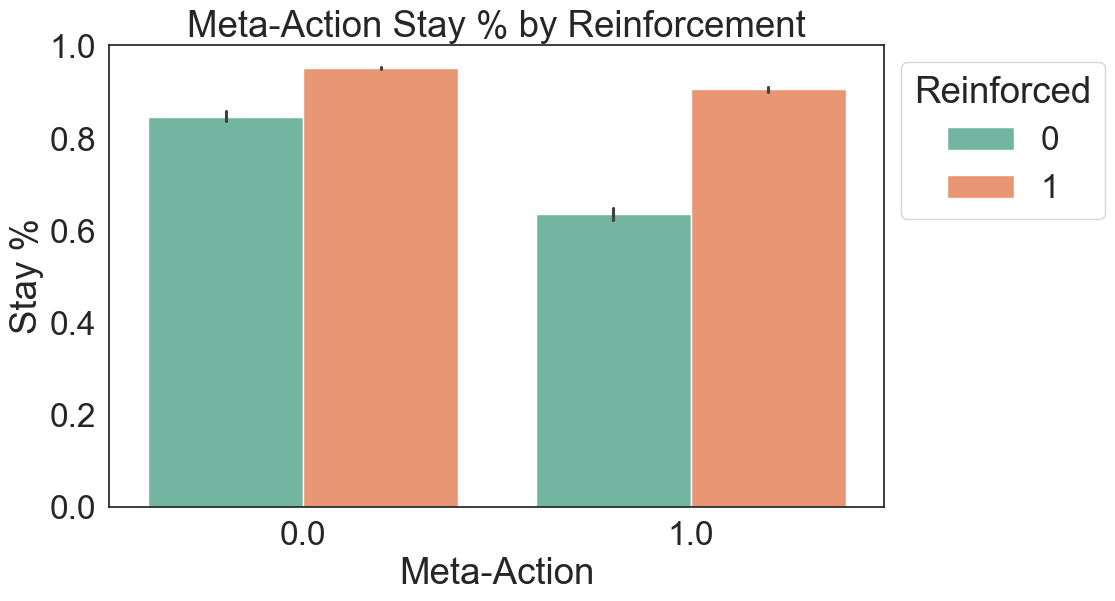

In [17]:
df['meta_action_stay'] = (df['choice_numeric'] == df['choice_numeric_last']).astype(int)
df_f = df[df['trial_num_within_goal'] > -1]
df_relevant = df_f

# Identify subjects who meet the condition
subjects_meeting_condition = df_relevant.groupby('sub').apply(
    lambda x: (x['got_to_goal'] > -1).all()
).reset_index(name='meets_condition')

# Filter to include only subjects who meet the condition for all their planning_depth == 3 trials
subjects_meeting_condition = subjects_meeting_condition[subjects_meeting_condition['meets_condition']]

# Step 3: Filter the original DataFrame to include only these subjects, regardless of their planning depth.
df_best_planning_subjects = df[df['sub'].isin(subjects_meeting_condition['sub'])]
df_best_planning_subjects=df_best_planning_subjects[df_best_planning_subjects['trial_num_within_goal']>1]
print(len(df_best_planning_subjects['sub'].unique()))
# average_got_to_goal = df_just_planning_2_1.groupby('sub')['got_to_goal'].mean()

# # Find subjects whose average `got_to_goal` is under 0.75
# subjects_to_remove = average_got_to_goal[average_got_to_goal < 0.75].index

# # Remove these subjects from `df_just_planning_2_1`
# df_just_planning_2_1 = df_just_planning_2_1[~df_just_planning_2_1['sub'].isin(subjects_to_remove)]

# Create a bar plot with 'choice_numeric_last' on x-axis, 'meta_switch' on y-axis, and 'got_to_goal_last' as hue
plt.figure(figsize=(10, 6))
sns.barplot(x='choice_numeric_last', y='meta_action_stay', hue='got_to_goal_last', data=df_best_planning_subjects, ci=68)

plt.title('Meta-Action Stay % by Reinforcement')
plt.xlabel('Meta-Action')
plt.ylabel('Stay %')
plt.legend(title='Reinforced', loc='upper left', bbox_to_anchor=(1, 1))

plt.savefig('meta_action_reinforcement_all.png',dpi=300)
plt.show()


In [18]:
trial_num_v = (df['trial_num'].values-0)/1.0
print(np.unique(trial_num_v))

[-1.         -0.98305085 -0.96610169 -0.94915254 -0.93220339 -0.91525424
 -0.89830508 -0.88135593 -0.86440678 -0.84745763 -0.83050847 -0.81355932
 -0.79661017 -0.77966102 -0.76271186 -0.74576271 -0.72881356 -0.71186441
 -0.69491525 -0.6779661  -0.66101695 -0.6440678  -0.62711864 -0.61016949
 -0.59322034 -0.57627119 -0.55932203 -0.54237288 -0.52542373 -0.50847458
 -0.49152542 -0.47457627 -0.45762712 -0.44067797 -0.42372881 -0.40677966
 -0.38983051 -0.37288136 -0.3559322  -0.33898305 -0.3220339  -0.30508475
 -0.28813559 -0.27118644 -0.25423729 -0.23728814 -0.22033898 -0.20338983
 -0.18644068 -0.16949153 -0.15254237 -0.13559322 -0.11864407 -0.10169492
 -0.08474576 -0.06779661 -0.05084746 -0.03389831 -0.01694915  0.        ]


In [ ]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import warnings

# Assuming 'df_RT' is already prepared and loaded
df_RT = df.copy()
print(df_RT['sub'].unique())
# df_RT = df[df['trial_num_within_goal'] != 1]
# df_RT['mean_optimal_delayed']=df_RT.groupby('sub')['optimally_delayed'].transform('mean')
# df_RT=df_RT[df_RT['mean_optimal_delayed']>0.34]

warnings.filterwarnings("ignore")

# Factorize 'sub' to use as indices for group-level effects
sub_idx, subs = pd.factorize(df_RT['sub'])
subject_median_rt = df_RT.groupby('sub')['RT'].transform('median')

# Normalize RT by dividing each RT by the respective median within subjects
df_RT['normalized_RT'] = df_RT['RT'] / subject_median_rt
# Convert 'planning_depth' and 'decision' from integers to categories 
# df_RT['planning_depth'] = pd.Categorical(df_RT['planning_depth']) 
# df_RT['decision'] = pd.Categorical(df_RT['decision'])

# Prepare data for modeling
RT = df_RT['RT'].values  # Assuming RT is the response variable you're modeling
delayed_planning = df_RT['delayed_planning'].values
trial_num_v = ((df_RT['trial_num_within_goal'].values-21)/20.0)
goalswitch = df_RT['goal_switch'].values
decision = df_RT['decision'].values
overplan = df_RT['over_planning'].values
meta_choice = df_RT['choice_numeric'].values
planning_depth = df_RT['planning_depth'].values
control_effect = df_RT['control_regressor'].values

interaction = delayed_planning * trial_num_v  # Interaction term

with pm.Model() as model_pymc:
    # Priors for fixed effects
    intercept = pm.Normal('intercept', mu=0, sigma=2)
    coef_delayed_planning = pm.Normal('coef_delayed_planning', mu=0, sigma=2)
    coef_trial_num = pm.Normal('coef_trial_num', mu=0, sigma=2)
    coef_goalswitch = pm.Normal('coef_goalswitch', mu=0, sigma=2)
    coef_decision = pm.Normal('coef_decision', mu=0, sigma=2)
    coef_planning_depth = pm.Normal('coef_planning_depth', mu=0, sigma=2)
    coef_c = pm.Normal('coef_c', mu=0, sigma=2)
    coef_interaction = pm.Normal('coef_interaction', mu=0, sigma=2)
    # error_var = pm.HalfNormal('error_c', 2)
    
    # Priors for random effects
    sigma_sub = pm.HalfNormal('sigma_sub', 2)
    intercept_sub = pm.Normal('intercept_sub', mu=0, sigma=sigma_sub, shape=len(subs))
    
    sigma_slope_dp = pm.HalfNormal('sigma_slope_dp', 2)
    slope_sub_dp = pm.Normal('slope_sub_dp', mu=0, sigma=sigma_slope_dp, shape=len(subs))
    
    sigma_slope_c = pm.HalfNormal('sigma_slope_c', 2)
    slope_sub_c = pm.Normal('slope_sub_c', mu=0, sigma=sigma_slope_c, shape=len(subs))

    sigma_slope_gs = pm.HalfNormal('sigma_slope_gs', 2)
    slope_sub_gs = pm.Normal('slope_sub_gs', mu=0, sigma=sigma_slope_gs, shape=len(subs))

    sigma_slope_d = pm.HalfNormal('sigma_slope_d', 2)
    slope_sub_d = pm.Normal('slope_sub_d', mu=0, sigma=sigma_slope_d, shape=len(subs))

    sigma_slope_pd = pm.HalfNormal('sigma_slope_pd', 2)
    slope_sub_pd = pm.Normal('slope_sub_pd', mu=0, sigma=sigma_slope_pd, shape=len(subs))

    sigma_slope_tn = pm.HalfNormal('sigma_slope_tn', 2)
    slope_sub_tn = pm.Normal('slope_sub_tn', mu=0, sigma=sigma_slope_tn, shape=len(subs))

    sigma_slope_interaction = pm.HalfNormal('sigma_slope_interaction', 2)
    slope_sub_interaction = pm.Normal('slope_sub_interaction', mu=0, sigma=sigma_slope_interaction, shape=len(subs))
    
    # Linear model
    mu = (intercept + intercept_sub[sub_idx] + 
          (coef_delayed_planning + slope_sub_dp[sub_idx]) * delayed_planning + 
          (coef_trial_num + slope_sub_tn[sub_idx]) * trial_num_v + 
          (coef_goalswitch + slope_sub_gs[sub_idx]) * goalswitch + 
          (coef_decision + slope_sub_d[sub_idx]) * decision + 
          (coef_c + slope_sub_c[sub_idx]) * control_effect + 
          (coef_planning_depth + slope_sub_pd[sub_idx]) * planning_depth + 
          (coef_interaction + slope_sub_interaction[sub_idx]) * interaction)
    
    # Assuming RT is continuous; use appropriate distribution if otherwise
    RT_obs = pm.Normal('RT_obs', mu=mu, sigma=1, observed=RT)
    
    # Inference
    trace2 = pm.sample(draws=1000, tune=1000, target_accept=0.99)


In [20]:
# trace2.to_netcdf("RTdata_model_fitted_withintrial.nc") 
trace2=az.from_netcdf("RTdata_model_fitted_withintrial.nc")

print(az.summary(trace2, var_names=['intercept','coef_trial_num','coef_delayed_planning','coef_trial_num','coef_goalswitch',
                                    'coef_decision','coef_planning_depth','coef_c',
                                    'coef_interaction'], hdi_prob=0.95))


                        mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
intercept              0.685  0.116     0.462      0.917      0.004    0.002   
coef_trial_num        -1.343  0.066    -1.468     -1.208      0.002    0.001   
coef_delayed_planning  0.302  0.062     0.182      0.423      0.001    0.001   
coef_goalswitch        0.132  0.020     0.093      0.170      0.000    0.000   
coef_decision         -0.536  0.046    -0.629     -0.448      0.002    0.001   
coef_planning_depth   -0.073  0.027    -0.123     -0.018      0.000    0.000   
coef_c                -0.129  0.065    -0.251      0.006      0.001    0.001   
coef_interaction       0.218  0.063     0.098      0.346      0.001    0.001   

                       ess_bulk  ess_tail  r_hat  
intercept                 985.0    1648.0    1.0  
coef_trial_num           1815.0    1966.0    1.0  
coef_delayed_planning    2011.0    2235.0    1.0  
coef_goalswitch          5771.0    2726.0    1.0  
coef_decision           

81
'coef_delayed_planning' - Mode: 0.30, 95% HDI: [0.18, 0.42]
'coef_interaction' - Mode: 0.21, 95% HDI: [0.10, 0.35]


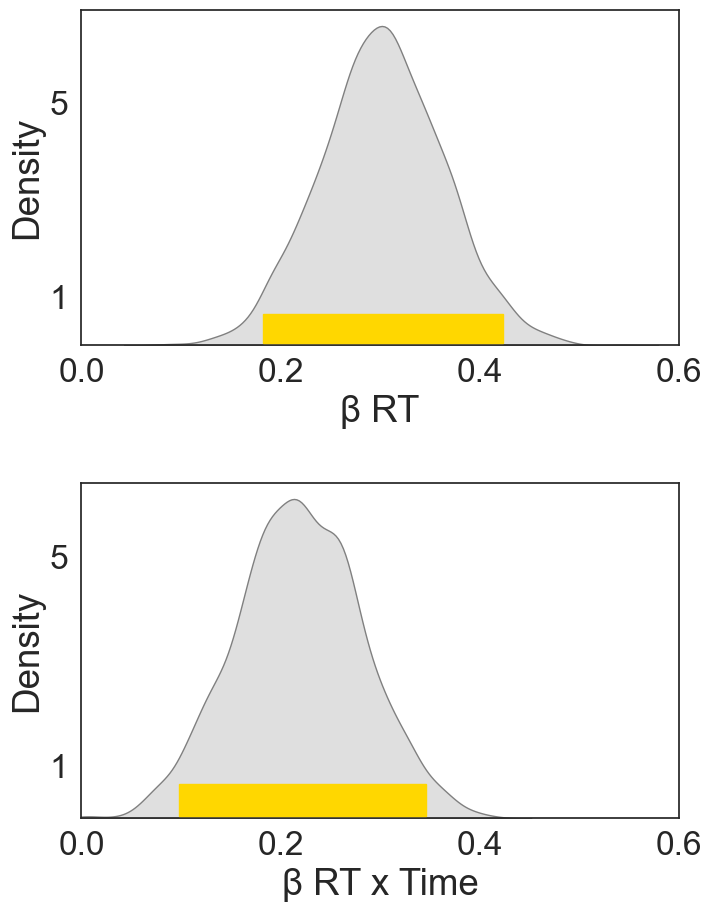

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az
from scipy.stats import gaussian_kde

# Assuming 'df1' and 'trace_acc' are defined earlier in your script...
trace_acc = trace2

# Convert subject IDs to indices for group-level parameters
sub_idx, subs = pd.factorize(df['sub'])
print(len(subs))

# Function to calculate mode
def calc_mode(data):
    kde = gaussian_kde(data)
    x_vals = np.linspace(min(data), max(data), 1000)
    mode = x_vals[np.argmax(kde(x_vals))]
    return mode

# Function to get mode and HDI
def get_mode_and_hdi(data, hdi_prob=0.95):
    mode = calc_mode(data)
    hdi = az.hdi(data, hdi_prob=hdi_prob)
    return mode, hdi

# Extract and print posterior samples for 'coef_delayed_planning'
posterior_samples = trace_acc.posterior['coef_delayed_planning'].values.flatten()
mode, hdi = get_mode_and_hdi(posterior_samples)
print(f"'coef_delayed_planning' - Mode: {mode:.2f}, 95% HDI: [{hdi[0]:.2f}, {hdi[1]:.2f}]")

# Extract and print posterior samples for 'coef_interaction'
posterior_samples = trace_acc.posterior['coef_interaction'].values.flatten()
mode, hdi = get_mode_and_hdi(posterior_samples)
print(f"'coef_interaction' - Mode: {mode:.2f}, 95% HDI: [{hdi[0]:.2f}, {hdi[1]:.2f}]")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az
from scipy.stats import gaussian_kde

# Assuming 'df1' and 'trace_acc' are defined earlier in your script...
trace_acc = trace2

# Convert subject IDs to indices for group-level parameters
sub_idx, subs = pd.factorize(df['sub'])

# Function to calculate mode
def calc_mode(data):
    kde = gaussian_kde(data)
    x_vals = np.linspace(min(data), max(data), 1000)
    mode = x_vals[np.argmax(kde(x_vals))]
    return mode

# Plotting the posterior distributions on the same grid
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=False)

# Increase text size
sns.set(font_scale=3, style='white')

# Extract and plot posterior samples for 'coef_delayed_planning'
posterior_samples = trace_acc.posterior['coef_delayed_planning'].values.flatten()
sns.kdeplot(posterior_samples, shade=True, color="gray", ax=ax1)
hdi = az.hdi(posterior_samples, hdi_prob=0.95)
mode = calc_mode(posterior_samples)
ax1.add_patch(plt.Rectangle((hdi[0], 0.05), hdi[1] - hdi[0], 0.6, color="gold", zorder=12))
ax1.set_ylabel('Density')
ax1.set_xlabel('\u03B2 RT')  # Set x-axis title
ax1.set_xlim([0, 0.6])  # Set x-axis limits
ax1.set_yticks([1,5])  # Set y-axis ticks


# Extract and plot posterior samples for 'coef_interaction'
posterior_samples = trace_acc.posterior['coef_interaction'].values.flatten()
sns.kdeplot(posterior_samples, shade=True, color="gray", ax=ax2)
hdi = az.hdi(posterior_samples, hdi_prob=0.95)
mode = calc_mode(posterior_samples)
ax2.add_patch(plt.Rectangle((hdi[0], 0.05), hdi[1] - hdi[0], 0.6, color="gold", zorder=12))
ax2.set_xlabel('\u03B2 RT x Time')  # Set x-axis title
ax2.set_ylabel('Density')
ax2.set_xlim([0, 0.6])  # Set x-axis limits
ax2.set_yticks([1,5])  # Set y-axis ticks


# Adjust the space between plots
plt.subplots_adjust(hspace=0.4)
plt.tight_layout()
plt.savefig('posterior_distributions.png', dpi=300, bbox_inches='tight')
plt.show()



# Computational Parameters Analysis

                        mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
coef_delayed_planning  0.302  0.062     0.182      0.423      0.001    0.001   
coef_interaction       0.218  0.063     0.098      0.346      0.001    0.001   

                       ess_bulk  ess_tail  r_hat  
coef_delayed_planning    2011.0    2235.0    1.0  
coef_interaction         4174.0    2240.0    1.0  


81
81
Delayed‐planning vs optimal delay (Spearman): r = 0.7030, p = 0.0000 [Shapiro p-values: x=0.000, y=0.000]


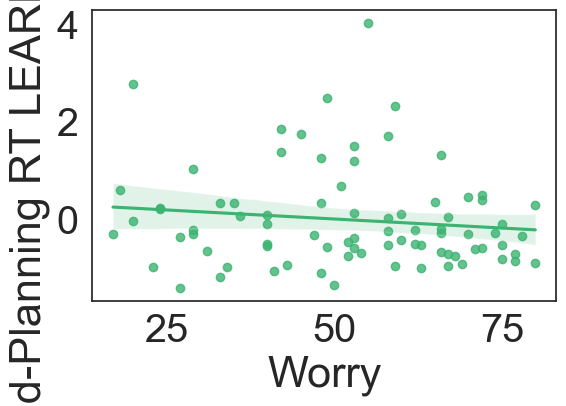

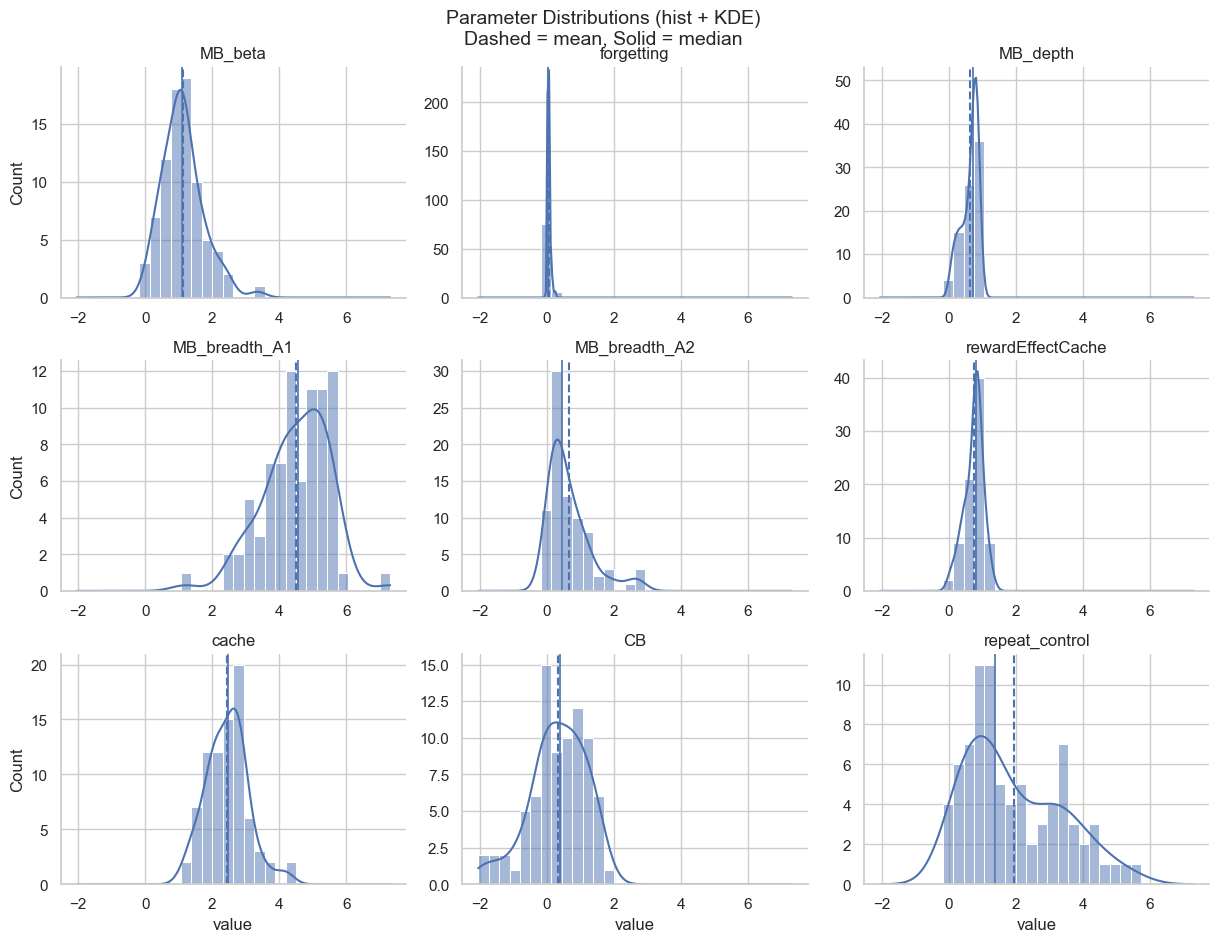


── OLS predicting MB_RT_effect ────────────────────────────────────
                    Robust linear Model Regression Results                    
Dep. Variable:           MB_RT_effect   No. Observations:                   81
Model:                            RLM   Df Residuals:                       73
Method:                          IRLS   Df Model:                            7
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Wed, 07 Oct 2026                                         
Time:                        10:44:14                                         
No. Iterations:                    20                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

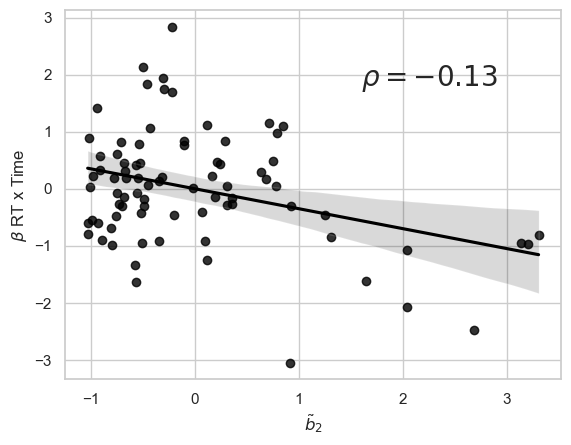

RT effect vs breadth₂ (Spearman): r = 0.4972, p = 0.0000 [Shapiro p-values: x=0.000, y=0.000]


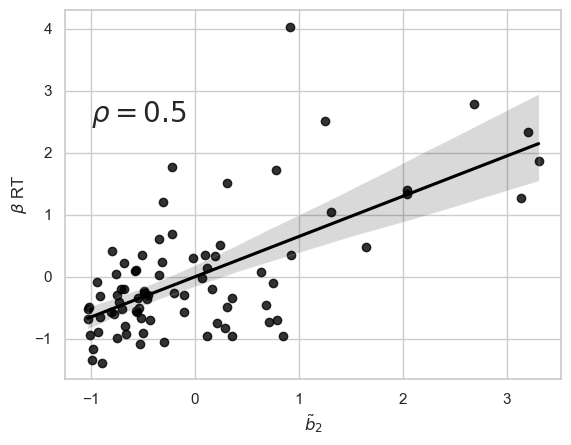

RT effect vs depth (Spearman): r = 0.1914, p = 1.0000 [Shapiro p-values: x=0.000, y=0.000]


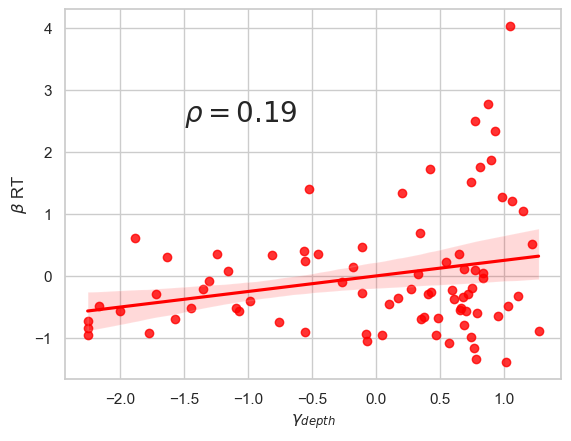

RT effect vs MB_beta (Spearman): r = 0.3311, p = 0.0457 [Shapiro p-values: x=0.000, y=0.005]


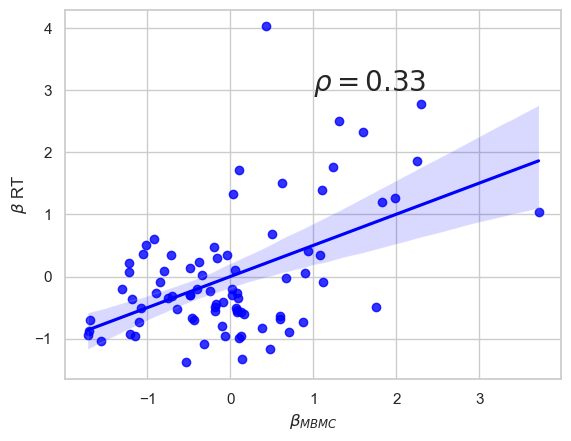

RT effect vs CB (Spearman): r = -0.1467, p = 1.0000 [Shapiro p-values: x=0.000, y=0.012]


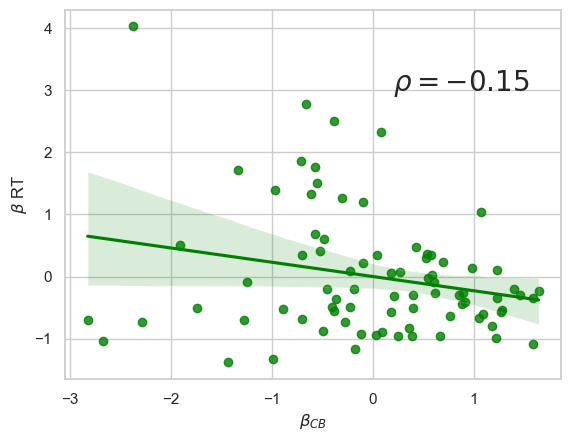

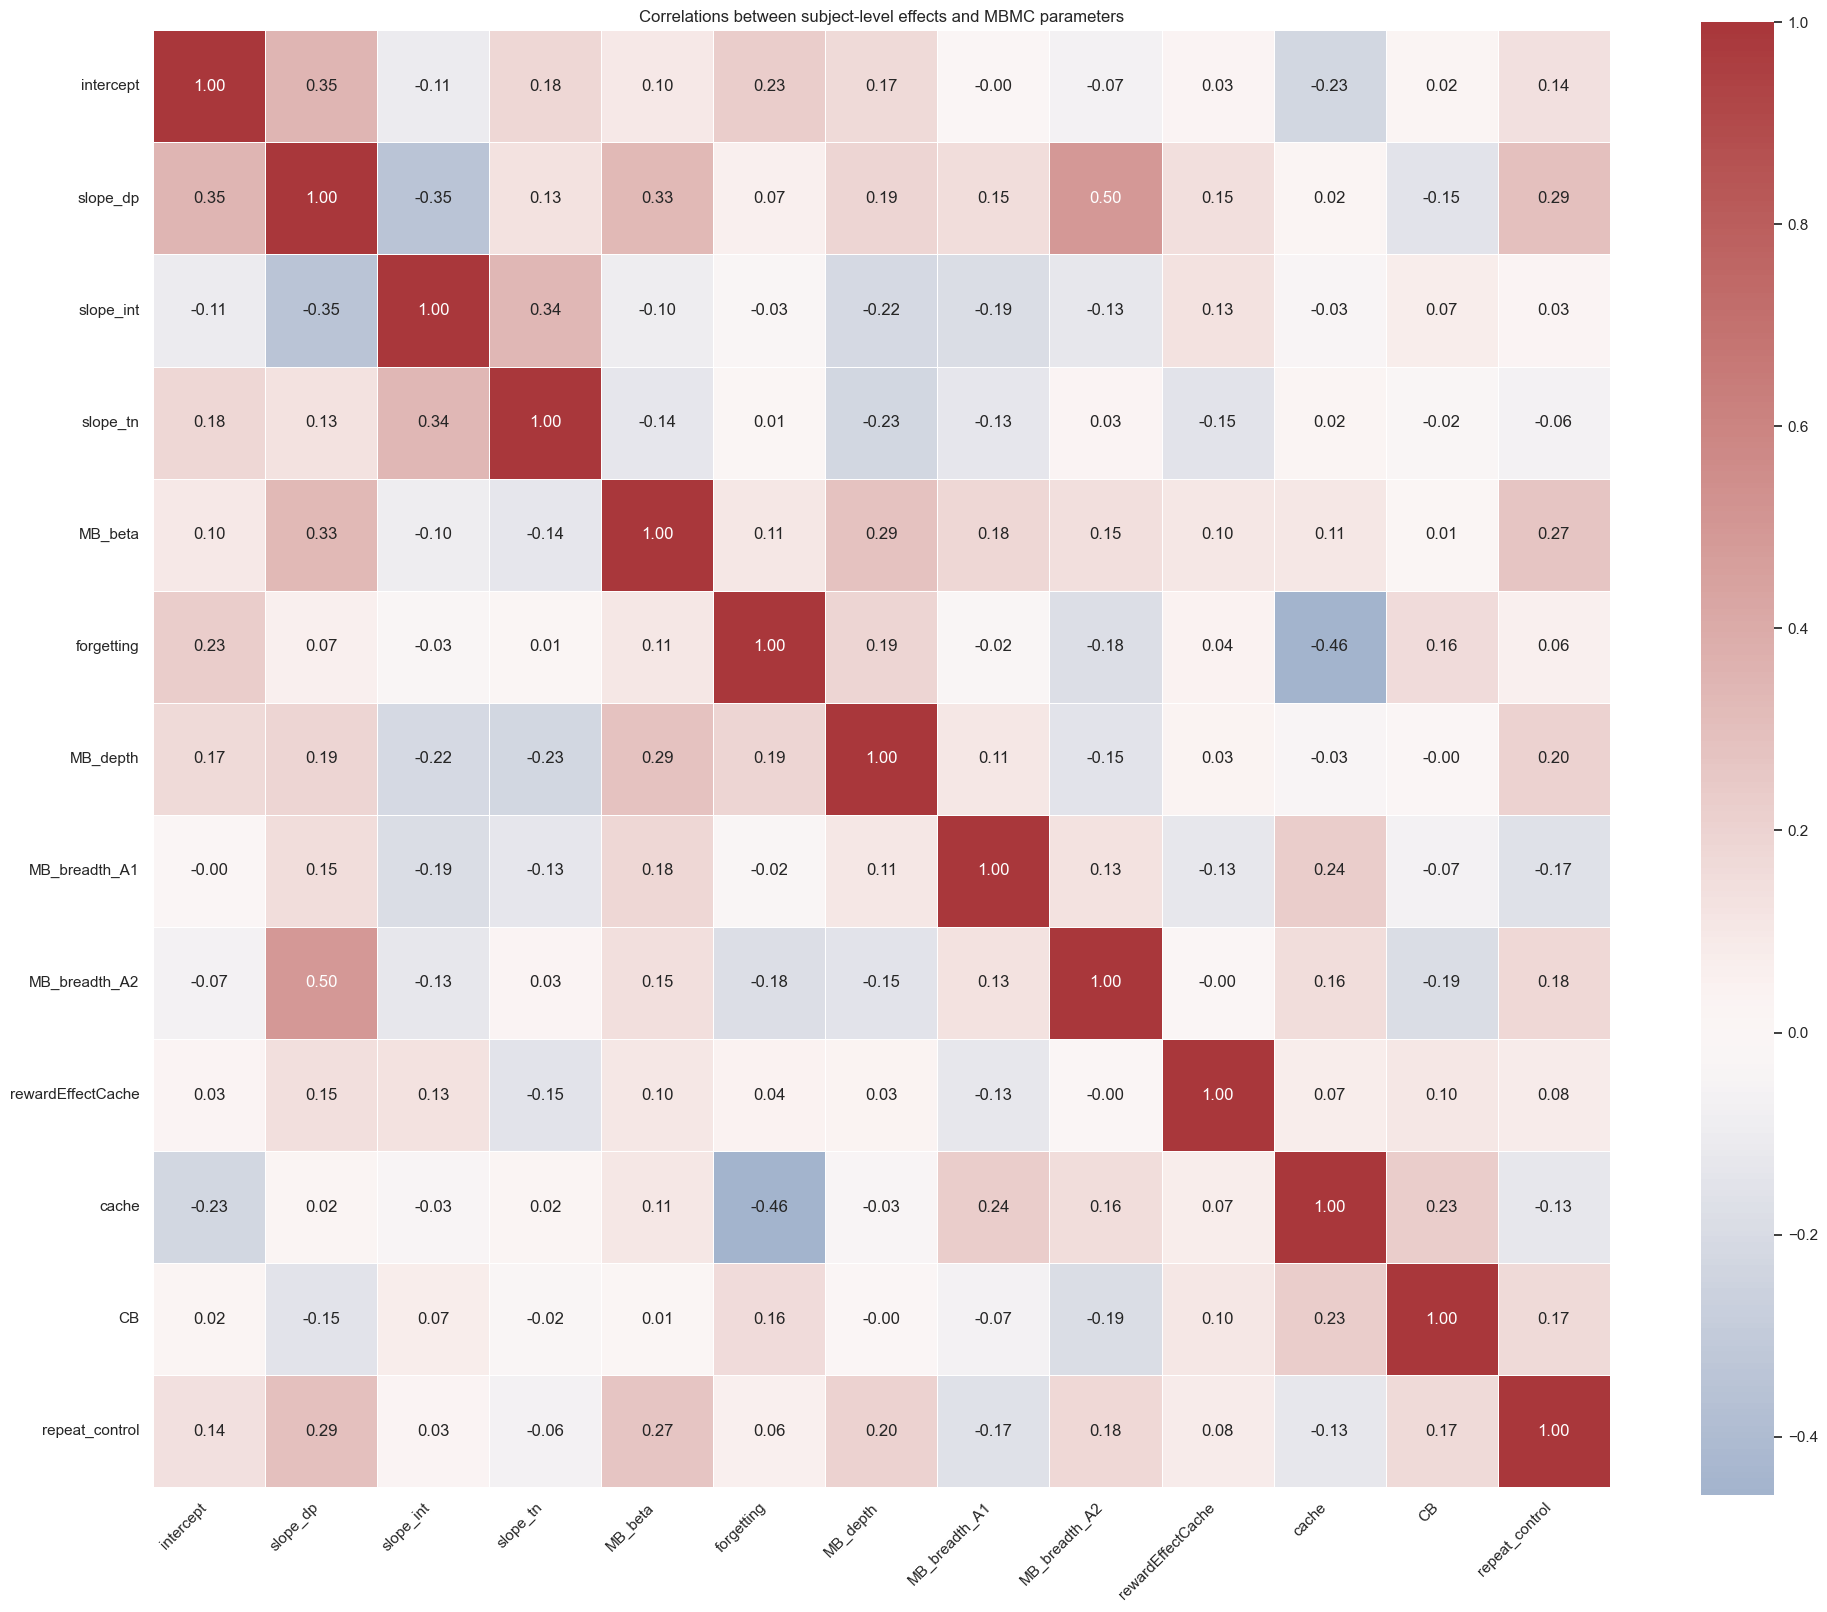

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr, shapiro
trace3=trace2
# ─── Settings ───────────────────────────────────────────────────────────────
sns.set(font_scale=2.6, style="white")

def normalize_array(x):
    """Z‐score normalize a 1D array or pandas Series."""
    return (x-x.mean())/x.std()

def auto_corr(x, y, alpha=0.05, label=""):
    """
    Test normality of x and y (Shapiro–Wilk).
    If both are normal, use Pearson; otherwise Spearman.
    Prints test used and returns (r, p).
    """
    sx, px = shapiro(x)
    sy, py = shapiro(y)
    method = "Pearson" if (px > alpha and py > alpha) else "Spearman"
    if method == "Pearson":
        r, p = pearsonr(x, y)
        
    else:
        r, p = spearmanr(x, y)

    p=p*18
    p=np.clip(p,0,1)
    print(f"{label} ({method}): r = {r:.4f}, p = {p:.4f}"
          + (f" [Shapiro p-values: x={px:.3f}, y={py:.3f}]" if method=="Spearman" else ""))
    return r, p

# ─── 1. Summarize posterior ─────────────────────────────────────────────────
trace2 = trace3
print(az.summary(trace2, var_names=['coef_delayed_planning', 'coef_interaction'], hdi_prob=0.95))

# ─── 2. Prepare per‐subject random effects & behavioral measures ─────────────
sub_idx, subs = pd.factorize(df['sub'])

# extract & normalize all sub‐level effects in a dict
posterior_means = trace2.posterior.mean(dim=['chain', 'draw'])
effects = {
    'intercept': 'intercept_sub',
    'slope_dp': 'slope_sub_dp',
    'slope_int': 'slope_sub_interaction',
    'slope_tn': 'slope_sub_tn',
}
for name, var in effects.items():
    effects[name] = normalize_array(posterior_means[var].values)

# group‐level means
group = df.groupby('sub')
worry = group['worry'].mean().reindex(subs).values
opt_delay = group['optimally_delayed'].mean().reindex(subs).values
print(len(opt_delay))
print(len(effects['slope_dp']))
memory = group['percent_correct'].mean().reindex(subs).values
performance = group['got_to_goal'].mean().reindex(subs).values

# ─── 3. Correlation & scatter: delayed‐planning slope vs optimal delay ────────
r, p = auto_corr(effects['slope_dp'], opt_delay,
                  label="Delayed‐planning vs optimal delay")
sns.regplot(x=worry, y=effects['slope_dp'], color='mediumseagreen')
plt.xlabel('Worry')
plt.ylabel('Delayed-Planning RT LEARNING Effect')
plt.tight_layout()
plt.show()

# ─── 4. Load & normalize model parameters ────────────────────────────────────
params = {

    'MB_beta':        np.load('MB_B_exec.npy'),
    'forgetting': np.load('forget_exec.npy'),
    'MB_depth':       np.load('MB_depth_exec.npy'),
    'MB_breadth_A1':  np.load('MB_breadth_exec.npy') * 8,
    'MB_breadth_A2':  np.load('breadth2_exec.npy')   * 4,
    'rewardEffectCache':       np.load('cache_reward_exec.npy'),
    'cache':     np.load('mbcache_exec.npy'),
    'CB':             np.load('cb_exec.npy'),
    'repeat_control':             np.load('cache_plan_exec.npy'),

}
# Build a DataFrame (assumes equal-length vectors; if not, pad/align as needed)
df = pd.DataFrame(params)

# Clean: drop NaNs/inf (per-column cleaning via melt makes it simpler)
long_df = (
    df.melt(var_name='parameter', value_name='value')
      .replace([np.inf, -np.inf], np.nan)
      .dropna(subset=['value'])
)

# ---------- Plot ----------
sns.set(style='whitegrid')
g = sns.displot(
    data=long_df,
    x='value',
    col='parameter',
    col_wrap=3,      # change to 4 if you want a wider grid
    kde=True,
    bins=30,
    height=3.2,
    aspect=1.3,
    facet_kws={'sharex': False, 'sharey': False}
)

# Add mean & median lines to each facet
for ax in g.axes.flatten():
    # Get the parameter name for this facet
    title = ax.get_title()                    # e.g., "parameter = MB_beta"
    param = title.split(' = ', 1)[-1] if ' = ' in title else title
    vals = long_df.loc[long_df['parameter'] == param, 'value']
    if len(vals) == 0:
        continue
    mean_v = vals.mean()
    med_v = vals.median()
    ax.axvline(mean_v, linestyle='--', linewidth=1.5)
    ax.axvline(med_v, linestyle='-',  linewidth=1.2)
    ax.set_title(param)

# Add a common legend-like note
g.figure.subplots_adjust(top=0.92)
g.figure.suptitle('Parameter Distributions (hist + KDE)\nDashed = mean, Solid = median', fontsize=14)

plt.show()

for k, v in params.items():
    params[k] = normalize_array(v)

# ─── 5. Build DataFrame & fit OLS models ─────────────────────────────────────
data = pd.DataFrame({
    'const': 1,
    'MB_RT_effect':  effects['slope_dp'],
    'MB_RT_over_time': effects['slope_int'],
    'RT_sub':         effects['intercept'],
    'worry':          worry,
    'performance':    performance,
    **params
})
features = ['MB_beta','MB_breadth_A1','MB_breadth_A2',
            'MB_depth','CB','rewardEffectCache','cache','forgetting']

for outcome in ['MB_RT_effect', 'MB_RT_over_time', 'RT_sub']:
    print(f"\n── OLS predicting {outcome} ────────────────────────────────────")
    model = sm.RLM(data[outcome], data[features])
    result = model.fit()
    print(result.summary())
    # test correlation with MB_beta
    auto_corr(data[outcome], data['MB_beta'],
              label=f"{outcome} vs MB_beta")

# ─── 6. Additional correlations & plots ──────────────────────────────────────
# correlation RT_over_time vs MB_breadth_A2
r, p = auto_corr(effects['slope_int'], params['MB_breadth_A2'],
                  label="RT x Time vs breadth₂")
print('cache rwd + B RT effect')
r1, p1 = auto_corr(effects['slope_int'], params['rewardEffectCache'],
                  label="RT x Time vs Cache Rwd LR")

sns.regplot(x='MB_breadth_A2', y='MB_RT_over_time', data=data, color='black')
plt.xlabel(r"$\tilde b_2$")
plt.ylabel(r"$\beta$ RT x Time")
plt.text(1.6, 1.8, r"$\rho = {}$".format(round(r,2)), fontsize=20)
plt.savefig('MB_BothAction_RTinteraction.png', dpi=300, bbox_inches='tight')
plt.show()

# correlation RT_effect vs MB_breadth_A2
r, p = auto_corr(effects['slope_dp'], params['MB_breadth_A2'],
                  label="RT effect vs breadth₂")
sns.regplot(x='MB_breadth_A2', y='MB_RT_effect', data=data, color='black')
plt.xlabel(r"$\tilde b_2$")
plt.ylabel(r"$\beta$ RT")
plt.text(-1, 2.5, r"$\rho = {}$".format(round(r,2)), fontsize=20)
plt.savefig('MB_BothAction_RTMAIN.png', dpi=300, bbox_inches='tight')
plt.show()

# depth
r, p = auto_corr(effects['slope_dp'], params['MB_depth'],
                  label="RT effect vs depth")
sns.regplot(x='MB_depth', y='MB_RT_effect', data=data, color='red')
plt.xlabel(r"$\gamma_{depth}$")
plt.ylabel(r"$\beta$ RT")
plt.text(-1.5, 2.5, r"$\rho = {}$".format(round(r,2)), fontsize=20)
plt.savefig('MB_Depth_RTMAIN.png', dpi=300, bbox_inches='tight')
plt.show()

# MB_beta
r, p = auto_corr(effects['slope_dp'], params['MB_beta'],
                  label="RT effect vs MB_beta")
sns.regplot(x='MB_beta', y='MB_RT_effect', data=data, color='blue')
plt.xlabel(r"$\beta_{MBMC}$")
plt.ylabel(r"$\beta$ RT")
plt.text(1, 3, r"$\rho = {}$".format(round(r,2)), fontsize=20)
plt.savefig('MBBeta_RTMAIN.png', dpi=300, bbox_inches='tight')
plt.show()

r, p = auto_corr(effects['slope_dp'], params['CB'],
                  label="RT effect vs CB")
sns.regplot(x='CB', y='MB_RT_effect', data=data, color='green')
plt.xlabel(r"$\beta_{CB}$")
plt.ylabel(r"$\beta$ RT")
plt.text(0.2, 3, r"$\rho = {}$".format(round(r,2)), fontsize=20)
plt.savefig('CB_RTMAIN.png', dpi=300, bbox_inches='tight')
plt.show()

# ─── 7. Combine effects + parameters & visualise correlations ────────────────
cols_effects = ['intercept', 'slope_dp', 'slope_int', 'slope_tn']
effects_df   = pd.DataFrame({k: effects[k] for k in cols_effects})

params_df    = pd.DataFrame(params)           # already z-scored above
combined_df  = pd.concat([effects_df, params_df], axis=1)

# correlation matrix
corr = combined_df.corr(method='spearman')

# heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(
    corr,
    annot=True, fmt=".2f", cmap="vlag", center=0,
    linewidths=.5, square=True, cbar_kws={"shrink": .75}
)
plt.title("Correlations between subject-level effects and MBMC parameters")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("param_effects_corr_heatmap.png", dpi=300)
plt.show()